In [2]:
from src.glcm_features.features import (compute_glcms, pre_feature_statistics, 
                                        compute_autocorrelation,      
                                        compute_cluster_prominence, 
                                        compute_cluster_shade,
                                        compute_cluster_tendency,
                                        compute_difference_average, 
                                        compute_inverse_variance,
                                        compute_inverse_difference_moment,
                                        compute_joint_average,
                                        compute_maximum_probability,
                                        compute_maximal_correlation_coefficient,
                                        compute_entropy,
                                        compute_difference_entropy,
                                        compute_difference_variance,
                                        compute_inverse_difference,
                                        compute_sum_average,
                                        compute_sum_entropy,
                                        compute_sum_of_squares,
                                        compute_information_measure_correlation_1,
                                        compute_information_measure_correlation_2
                                        )

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib import axes
from skimage.feature import graycomatrix, graycoprops

In [12]:
def compute_samples(dice_settings, num_samples=100, size=(8, 8)):
    image_samples = {}
    sample_features = {}
    
    outcomes = [0, 1, 2, 3]
    
    for p_idx, probabilities in enumerate(dice_settings):
        samples_list = []
        features_list = []

        for i in range(num_samples):
            # Generate the 8x8 image
            image = np.random.choice(outcomes, size=size, p=probabilities)
            samples_list.append(image)
            
            glcm_data = compute_glcms(image, levels=4)['mean']
            glcm_stats = pre_feature_statistics(glcm_data)
            glcm = glcm_stats['Pij']
            
            contrast = graycoprops(glcm, 'contrast')[0,0]
            energy = graycoprops(glcm, 'energy')[0,0]
            homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
            correlation = graycoprops(glcm, 'correlation')[0,0]

            autocorrelation = compute_autocorrelation(glcm_stats)
            cluster_prominence = compute_cluster_prominence(glcm_stats)
            cluster_shade = compute_cluster_shade(glcm_stats)
            cluster_tendency = compute_cluster_tendency(glcm_stats)
            difference_average = compute_difference_average(glcm_stats)
            difference_entropy = compute_difference_entropy(glcm_stats)
            difference_variance = compute_difference_variance(glcm_stats)
            entropy = compute_entropy(glcm_stats)
            inverse_difference = compute_inverse_difference(glcm_stats)
            inverse_difference_moment = compute_inverse_difference_moment(glcm_stats)
            inverse_variance = compute_inverse_variance(glcm_stats)
            imc1 = np.array(compute_information_measure_correlation_1(glcm_stats)).item()
            imc2 = np.array(compute_information_measure_correlation_2(glcm_stats)).item()
            joint_average = compute_joint_average(glcm_stats)
            maximum_probability = compute_maximum_probability(glcm_stats)
            maximal_correlation_coefficient = compute_maximal_correlation_coefficient(glcm_stats)
            sum_average = compute_sum_average(glcm_stats)
            sum_entropy = compute_sum_entropy(glcm_stats)
            sum_of_squares = compute_sum_of_squares(glcm_stats)
            
            features = [contrast, energy, homogeneity, correlation, 
                        autocorrelation, cluster_prominence, cluster_shade, 
                        cluster_tendency, difference_average, difference_entropy, 
                        difference_variance, entropy, inverse_difference, 
                        inverse_difference_moment, inverse_variance, 
                        imc1, imc2, sum_average, sum_entropy, sum_of_squares, 
                        joint_average, maximum_probability, 
                        maximal_correlation_coefficient, np.squeeze(glcm), image]
            
            features_list.append(features)
            
        image_samples[p_idx] = samples_list
        sample_features[p_idx] = features_list
        
    return image_samples, sample_features




In [13]:
p_settings = [
    [0.25, 0.25, 0.25, 0.25],
    [0.6, 0.1334, 0.1333, 0.1333],
    [0.1333, 0.1333, 0.1334, 0.6],
    [0.4, 0.4, 0.1, 0.1],
    [0.1, 0.1, 0.4, 0.4],
    [0.4, 0.1, 0.1, 0.4]
]
np.random.seed(25)

_, sample_features = compute_samples(p_settings, num_samples=1000)

In [14]:
FEATURE_NAMES = [
    "contrast", "energy", "homogeneity", "correlation", 
    "autocorrelation", 
    "cluster_prominence", "cluster_shade", "cluster_tendency", 
    "difference_average", "difference_entropy", "difference_variance",
    "entropy", "inverse_difference", "inverse_difference_moment", "inverse_variance", 
    "imc1", "imc2",
    "sum_average", "sum_entropy", "sum_of_squares", 
    "joint_average", "maximum_probability", "maximal_correlation_coefficient", 
    "glcm", "image"
]

rows = []
labels = [] 

for p_label, features_list in sample_features.items():
    for features in features_list:
        rows.append(features)
        labels.append(p_label)

df = pd.DataFrame(rows, columns=FEATURE_NAMES)
df['probability_set'] = labels

In [15]:
df['autocorrelation'] = df['autocorrelation'].apply(lambda x: x[0]).astype(float)
df['cluster_prominence'] = df['cluster_prominence'].apply(lambda x: x[0][0]).astype(float)
df['cluster_shade'] = df['cluster_shade'].apply(lambda x: x[0][0]).astype(float)
df['cluster_tendency'] = df['cluster_tendency'].apply(lambda x: x[0][0]).astype(float)
df['entropy'] = df['entropy'].apply(lambda x: x[0][0]).astype(float)
df['inverse_difference'] = df['inverse_difference'].apply(lambda x: x[0][0]).astype(float)
df['inverse_difference_moment'] = df['inverse_difference_moment'].apply(lambda x: x[0][0]).astype(float)
df['inverse_variance'] = df['inverse_variance'].apply(lambda x: x[0][0]).astype(float)
df['sum_of_squares'] = df['sum_of_squares'].apply(lambda x: x[0][0]).astype(float)
df['joint_average'] = df['joint_average'].apply(lambda x: x[0][0]).astype(float)


In [16]:
df.sample()

,contrast,energy,homogeneity,correlation,autocorrelation,cluster_prominence,cluster_shade,cluster_tendency,difference_average,difference_entropy,...,imc2,sum_average,sum_entropy,sum_of_squares,joint_average,maximum_probability,maximal_correlation_coefficient,glcm,image,probability_set
5631,3.880952,0.360838,0.482381,-0.063378,5.07619,25.331541,0.842414,3.418163,1.509524,1.32034,...,0.198889,4.557143,1.730887,1.813605,2.285714,0.219048,0.155493,"[[0.21904761904761905, 0.04285714285714286, 0....","[[0, 3, 0, 0, 3, 2, 3, 1], [0, 0, 0, 0, 0, 2, ...",5


## Testing

In [17]:
META_COLS = {"glcm", "image", "probability_set"}
FEATURE_COLS = [
    c for c in df.columns
    if c not in META_COLS and pd.api.types.is_numeric_dtype(df[c])
]

LOW_LO,  LOW_HI  = 0,  1   
HIGH_LO, HIGH_HI = 99, 100  

# Compute thresholds & binary label frames for both ends 
def make_label_frame(df, feature_cols, lo_pct, hi_pct, prefix):
    frame = pd.DataFrame(index=df.index)
    for feat in feature_cols:
        lo = df[feat].quantile(lo_pct / 100)
        hi = df[feat].quantile(hi_pct / 100)
        frame[f"{prefix} {feat}"] = df[feat].between(lo, hi, inclusive="both").astype(int)
    return frame

max_labels = make_label_frame(df, FEATURE_COLS, HIGH_LO, HIGH_HI, "Max")
min_labels = make_label_frame(df, FEATURE_COLS, LOW_LO,  LOW_HI,  "Min")

any_max = max_labels.any(axis=1)
any_min = min_labels.any(axis=1)

In [18]:
def cooccurrence_pairs(binary_df, feature_cols, col_prefix):
    """Upper-triangle co-occurrence as a ranked pairs DataFrame."""
    co = binary_df.T.dot(binary_df)
    co.index   = feature_cols
    co.columns = feature_cols

    upper = co.where(np.triu(np.ones(co.shape), k=1).astype(bool))
    pairs = (
        upper.stack(dropna=True)
             .reset_index()
             .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: f"Shared {col_prefix} Samples"})
             .drop_duplicates(subset=["Feature A", "Feature B"])
             .sort_values(f"Shared {col_prefix} Samples", ascending=False)
             .reset_index(drop=True)
    )
    return co, pairs

max_co, max_pairs = cooccurrence_pairs(max_labels[any_max], FEATURE_COLS, "Max")
min_co, min_pairs = cooccurrence_pairs(min_labels[any_min], FEATURE_COLS, "Min")


print(min_pairs.to_string(index=False))

                Feature A                       Feature B  Shared Min Samples
              homogeneity       inverse_difference_moment                63.0
          autocorrelation                     sum_average                53.0
              sum_average                   joint_average                50.0
       cluster_prominence                cluster_tendency                50.0
          autocorrelation                   joint_average                49.0
                 contrast              difference_entropy                48.0
       difference_entropy             difference_variance                46.0
                 contrast             difference_variance                44.0
                     imc2 maximal_correlation_coefficient                44.0
                   energy             maximum_probability                44.0
         cluster_tendency                  sum_of_squares                42.0
                  entropy                     sum_entropy       

/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_38627/1954045886.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  upper.stack(dropna=True)
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_38627/1954045886.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  upper.stack(dropna=True)


In [19]:
cross_matrix = max_labels.T.dot(min_labels)
cross_matrix.index   = [c.replace("Max ", "") for c in max_labels.columns]
cross_matrix.columns = [c.replace("Min ", "") for c in min_labels.columns]

print("\n=== Cross table: shared Max (rows) vs Min (cols) samples per feature pair ===\n")
print(cross_matrix.to_string())


=== Cross table: shared Max (rows) vs Min (cols) samples per feature pair ===

                                 contrast  energy  homogeneity  correlation  autocorrelation  cluster_prominence  cluster_shade  cluster_tendency  difference_average  difference_entropy  difference_variance  entropy  inverse_difference  inverse_difference_moment  inverse_variance  imc1  imc2  sum_average  sum_entropy  sum_of_squares  joint_average  maximum_probability  maximal_correlation_coefficient
contrast                                0       0           11            6                0                   0              0                 0                   0                   2                    0        0                   1                         11                13     0     0            0            0               0              0                    0                                0
energy                                  0       0            0            1               25                   0

In [23]:
cross_pairs = (
    cross_matrix.stack()
                .reset_index()
                .rename(columns={"level_0": "Max Feature", "level_1": "Min Feature", 0: "Shared Samples"})
                .query("`Max Feature` != `Min Feature`")   
                
                .sort_values("Shared Samples", ascending=False)
                .reset_index(drop=True)
)

print("\n=== Top cross-pairs: samples that maximise one feature and minimise another ===\n")
cross_pairs.head(30)


=== Top cross-pairs: samples that maximise one feature and minimise another ===



,Max Feature,Min Feature,Shared Samples
0,entropy,energy,56
1,imc1,imc2,51
2,energy,entropy,51
3,maximum_probability,entropy,48
4,imc2,imc1,45
5,inverse_difference,sum_entropy,42
6,imc1,maximal_correlation_coefficient,42
7,inverse_difference,entropy,41
8,energy,sum_entropy,41
9,entropy,maximum_probability,40


## Similarity tables

In [21]:
# Upper-triangle co-occurrence for Max and Min separately 
max_co = max_labels.T.dot(max_labels)
min_co = min_labels.T.dot(min_labels)

max_co.index = max_co.columns = FEATURE_COLS
min_co.index = min_co.columns = FEATURE_COLS

mask = np.triu(np.ones((len(FEATURE_COLS), len(FEATURE_COLS)), dtype=bool), k=1)

rows = []
for i, a in enumerate(FEATURE_COLS):
    for j, b in enumerate(FEATURE_COLS):
        if not mask[i, j]:
            continue
        shared_max = int(max_co.loc[a, b])
        shared_min = int(min_co.loc[a, b])
        rows.append({
            "Feature A":      a,
            "Feature B":      b,
            "Shared Max":     shared_max,
            "Shared Min":     shared_min,
            "Shared Max+Min": shared_max + shared_min,  # combined signal
        })

pairs = (
    pd.DataFrame(rows)
    .sort_values("Shared Max+Min", ascending=False)
    .reset_index(drop=True)
)

print("=== Feature pairs ranked by total shared extreme samples (Max + Min) ===\n")
print(pairs.to_string(index=False))

=== Feature pairs ranked by total shared extreme samples (Max + Min) ===

                Feature A                       Feature B  Shared Max  Shared Min  Shared Max+Min
              homogeneity       inverse_difference_moment          60          63             123
          autocorrelation                     sum_average          55          53             108
              sum_average                   joint_average          52          50             102
       cluster_prominence                cluster_tendency          51          50             101
                   energy             maximum_probability          57          44             101
          autocorrelation                   joint_average          48          49              97
                     imc2 maximal_correlation_coefficient          36          44              80
      difference_variance                  sum_of_squares          40          39              79
       inverse_difference       inverse_diff

In [22]:
max_thresh = 20
min_thresh = 20

strong_pairs = (
    pairs[
        (pairs["Shared Max"] >= max_thresh) &
        (pairs["Shared Min"] >= min_thresh)
    ]
    .sort_values("Shared Max+Min", ascending=False)
    .reset_index(drop=True)
)

print(f"    (Max threshold ≥ {max_thresh:.0f},  Min threshold ≥ {min_thresh:.0f})\n")
print(strong_pairs.to_string(index=False))

    (Max threshold ≥ 20,  Min threshold ≥ 20)

          Feature A                       Feature B  Shared Max  Shared Min  Shared Max+Min
        homogeneity       inverse_difference_moment          60          63             123
    autocorrelation                     sum_average          55          53             108
        sum_average                   joint_average          52          50             102
 cluster_prominence                cluster_tendency          51          50             101
             energy             maximum_probability          57          44             101
    autocorrelation                   joint_average          48          49              97
               imc2 maximal_correlation_coefficient          36          44              80
difference_variance                  sum_of_squares          40          39              79
 inverse_difference       inverse_difference_moment          47          31              78
        homogeneity              

## Autocorrelation

$$ \sum^{N}_{i=1} \sum^{N}_{j=1} (i \cdot j) p(i, j) $$

In [31]:
df_autocorrelation = df.sort_values(by=["autocorrelation"])[['autocorrelation', 'glcm', 'image']].reset_index()

df_autocorrelation

,index,autocorrelation,glcm,image
0,1147,2.000000,"[[0.5666666666666667, 0.09047619047619047, 0.0...","[[0, 0, 0, 3, 0, 0, 3, 0], [0, 0, 0, 0, 0, 0, ..."
1,1403,2.119048,"[[0.49523809523809526, 0.10952380952380952, 0....","[[0, 0, 3, 0, 0, 1, 0, 1], [0, 0, 0, 2, 0, 0, ..."
2,1110,2.123810,"[[0.5142857142857142, 0.11904761904761904, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 0], [2, 1, 0, 0, 0, 1, ..."
3,1523,2.166667,"[[0.5666666666666667, 0.0380952380952381, 0.11...","[[2, 1, 1, 0, 0, 3, 0, 0], [0, 1, 0, 0, 0, 0, ..."
4,1983,2.171429,"[[0.49047619047619045, 0.10476190476190476, 0....","[[1, 1, 0, 0, 0, 0, 0, 0], [2, 1, 0, 0, 2, 0, ..."
...,...,...,...,...
5995,2173,12.547619,"[[0.004761904761904762, 0.0, 0.028571428571428...","[[3, 0, 3, 3, 3, 0, 3, 3], [3, 3, 3, 3, 3, 3, ..."
5996,2377,12.642857,"[[0.0, 0.014285714285714285, 0.004761904761904...","[[1, 2, 3, 3, 2, 3, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5997,2734,12.771429,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."
5998,2052,12.828571,"[[0.004761904761904762, 0.0, 0.009523809523809...","[[3, 3, 3, 3, 3, 3, 3, 3], [3, 3, 3, 2, 3, 3, ..."


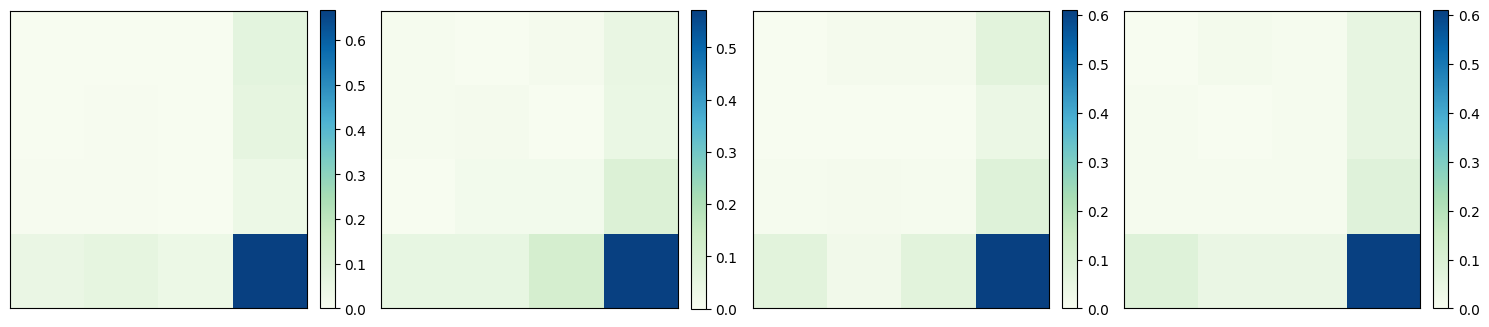

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_autocorrelation.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

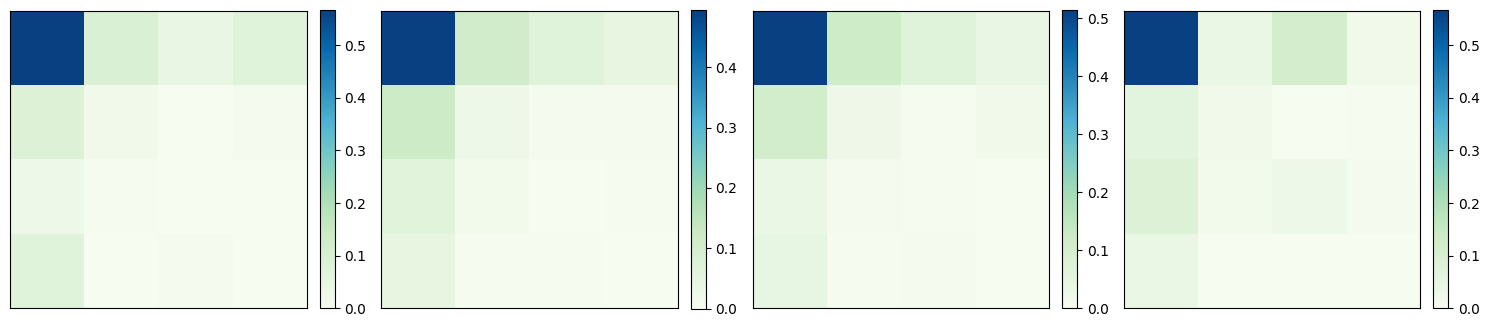

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_autocorrelation.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cluster prominence

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i + j - \mu_x - \mu_y)^4 p(i, j) $$

In [36]:
df_cluster_prominence = df.sort_values(by=["cluster_prominence"])[['cluster_prominence', 'glcm', 'image']].reset_index()

df_cluster_prominence

,index,cluster_prominence,glcm,image
0,3150,0.968833,"[[0.19047619047619047, 0.26666666666666666, 0....","[[1, 1, 0, 1, 0, 0, 2, 1], [0, 1, 0, 1, 0, 1, ..."
1,3663,1.317333,"[[0.2, 0.22380952380952382, 0.0095238095238095...","[[1, 1, 0, 0, 0, 2, 1, 0], [0, 1, 1, 1, 0, 1, ..."
2,4402,1.663647,"[[0.0, 0.0, 0.0, 0.0], [0.0, 0.004761904761904...","[[2, 2, 3, 1, 3, 3, 3, 3], [1, 2, 3, 2, 2, 3, ..."
3,3612,1.860644,"[[0.11428571428571428, 0.22857142857142856, 0....","[[0, 2, 1, 1, 0, 1, 1, 1], [1, 0, 0, 0, 0, 2, ..."
4,4435,2.040507,"[[0.0, 0.0, 0.0, 0.009523809523809525], [0.0, ...","[[3, 3, 2, 2, 2, 1, 2, 3], [2, 3, 2, 3, 2, 2, ..."
...,...,...,...,...
5995,5613,38.080322,"[[0.2, 0.05714285714285714, 0.0095238095238095...","[[2, 3, 3, 3, 0, 0, 0, 3], [3, 3, 0, 0, 0, 0, ..."
5996,5426,38.394360,"[[0.17142857142857143, 0.014285714285714285, 0...","[[3, 0, 0, 0, 3, 3, 3, 3], [0, 3, 3, 0, 0, 0, ..."
5997,5581,39.149833,"[[0.2619047619047619, 0.01904761904761905, 0.0...","[[0, 1, 1, 0, 1, 3, 0, 1], [0, 3, 0, 0, 0, 0, ..."
5998,5519,39.598060,"[[0.24285714285714285, 0.01904761904761905, 0....","[[0, 0, 3, 3, 3, 0, 2, 0], [0, 3, 3, 3, 0, 3, ..."


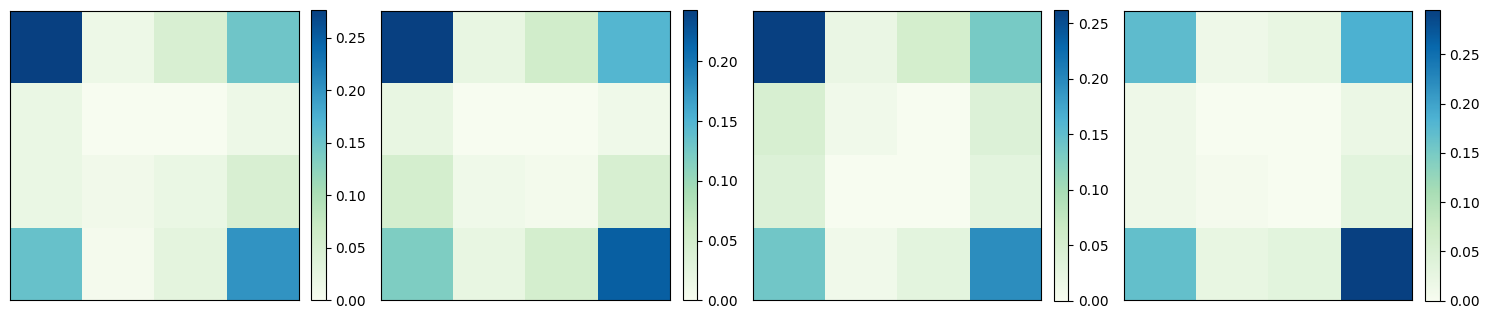

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_prominence.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

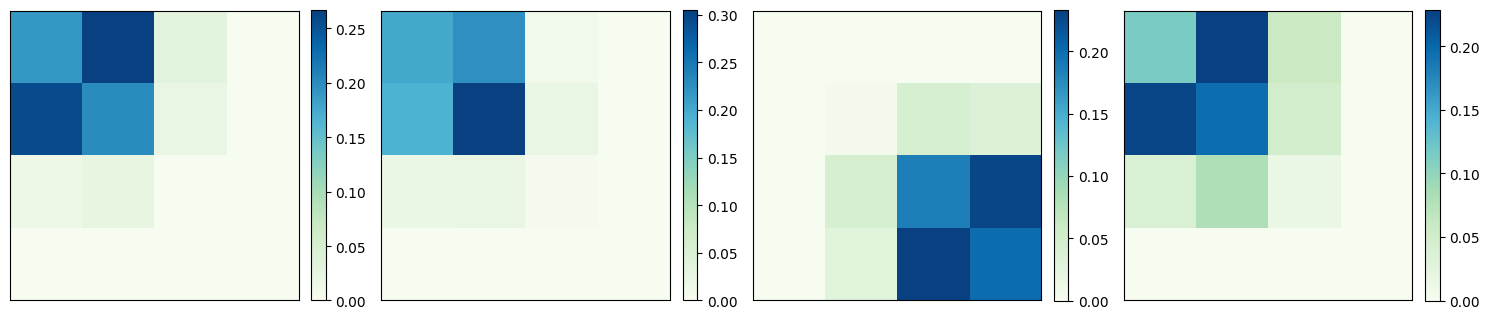

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_prominence.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cluster shade

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i + j - \mu_x - \mu_y)^3 p(i, j) $$

In [43]:
df_cluster_shade = df.sort_values(by=["cluster_shade"])[['cluster_shade', 'glcm', 'image']].reset_index()

df_cluster_shade

,index,cluster_shade,glcm,image
0,2299,-5.746074,"[[0.05238095238095238, 0.023809523809523808, 0...","[[3, 3, 1, 3, 0, 0, 3, 3], [0, 3, 3, 3, 3, 0, ..."
1,2861,-5.265374,"[[0.02857142857142857, 0.009523809523809525, 0...","[[3, 3, 3, 2, 3, 3, 1, 0], [3, 3, 3, 3, 3, 0, ..."
2,2149,-4.955850,"[[0.047619047619047616, 0.004761904761904762, ...","[[3, 2, 3, 3, 0, 3, 0, 0], [0, 2, 0, 2, 0, 2, ..."
3,2949,-4.914354,"[[0.02857142857142857, 0.03333333333333333, 0....","[[3, 2, 3, 3, 0, 3, 3, 3], [3, 3, 2, 3, 3, 3, ..."
4,2417,-4.622157,"[[0.02857142857142857, 0.014285714285714285, 0...","[[0, 3, 3, 3, 3, 3, 3, 2], [3, 3, 3, 3, 3, 0, ..."
...,...,...,...,...
5995,1204,4.658286,"[[0.5047619047619047, 0.06190476190476191, 0.0...","[[0, 0, 0, 0, 0, 3, 0, 0], [0, 0, 0, 0, 0, 0, ..."
5996,1639,4.674734,"[[0.5619047619047619, 0.04285714285714286, 0.0...","[[3, 0, 0, 0, 3, 0, 0, 2], [0, 3, 0, 0, 0, 0, ..."
5997,1691,4.865353,"[[0.49047619047619045, 0.06666666666666667, 0....","[[0, 0, 0, 0, 1, 0, 0, 2], [0, 0, 0, 0, 0, 0, ..."
5998,1832,5.722286,"[[0.45714285714285713, 0.09047619047619047, 0....","[[0, 3, 1, 3, 0, 1, 2, 1], [3, 3, 0, 0, 0, 1, ..."


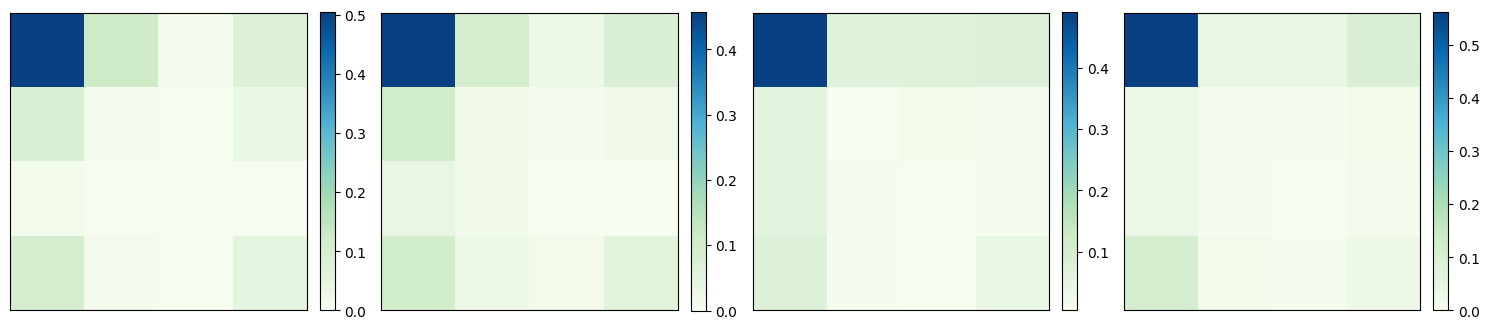

In [59]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_shade.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

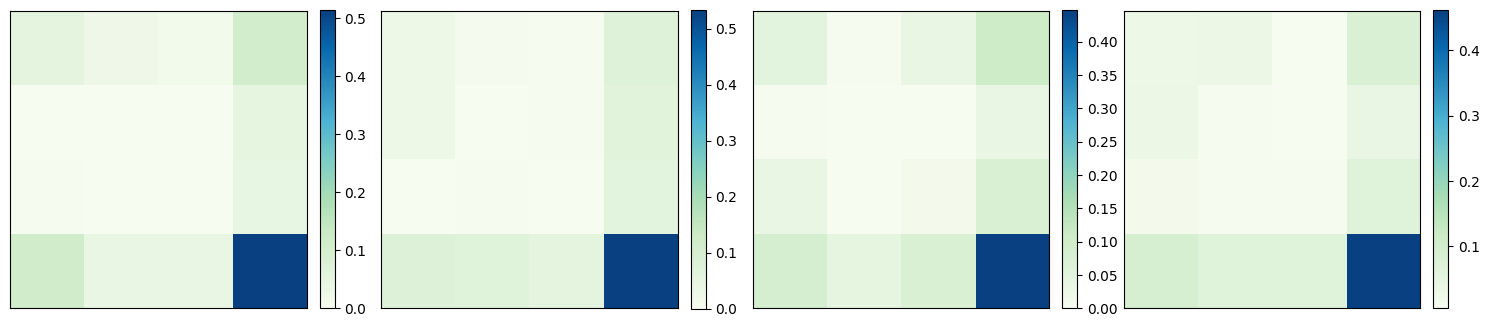

In [60]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_shade.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cluster Tendency

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i + j - \mu_x - \mu_y)^2 p(i, j) $$

In [46]:
df_cluster_tendency = df.sort_values(by=["cluster_tendency"])[['cluster_tendency', 'glcm', 'image']].reset_index()

df_cluster_tendency

,index,cluster_tendency,glcm,image
0,3150,0.585692,"[[0.19047619047619047, 0.26666666666666666, 0....","[[1, 1, 0, 1, 0, 0, 2, 1], [0, 1, 0, 1, 0, 1, ..."
1,3663,0.707687,"[[0.2, 0.22380952380952382, 0.0095238095238095...","[[1, 1, 0, 0, 0, 2, 1, 0], [0, 1, 1, 1, 0, 1, ..."
2,4402,0.778889,"[[0.0, 0.0, 0.0, 0.0], [0.0, 0.004761904761904...","[[2, 2, 3, 1, 3, 3, 3, 3], [1, 2, 3, 2, 2, 3, ..."
3,3612,0.820862,"[[0.11428571428571428, 0.22857142857142856, 0....","[[0, 2, 1, 1, 0, 1, 1, 1], [1, 0, 0, 0, 0, 2, ..."
4,4435,0.845828,"[[0.0, 0.0, 0.0, 0.009523809523809525], [0.0, ...","[[3, 3, 2, 2, 2, 1, 2, 3], [2, 3, 2, 3, 2, 2, ..."
...,...,...,...,...
5995,5378,4.472766,"[[0.20952380952380953, 0.01904761904761905, 0....","[[0, 3, 3, 1, 1, 3, 3, 0], [3, 0, 0, 3, 0, 1, ..."
5996,5613,4.553651,"[[0.2, 0.05714285714285714, 0.0095238095238095...","[[2, 3, 3, 3, 0, 0, 0, 3], [3, 3, 0, 0, 0, 0, ..."
5997,5581,4.683469,"[[0.2619047619047619, 0.01904761904761905, 0.0...","[[0, 1, 1, 0, 1, 3, 0, 1], [0, 3, 0, 0, 0, 0, ..."
5998,5048,4.799184,"[[0.2761904761904762, 0.014285714285714285, 0....","[[3, 3, 0, 0, 0, 0, 0, 2], [3, 0, 0, 0, 0, 0, ..."


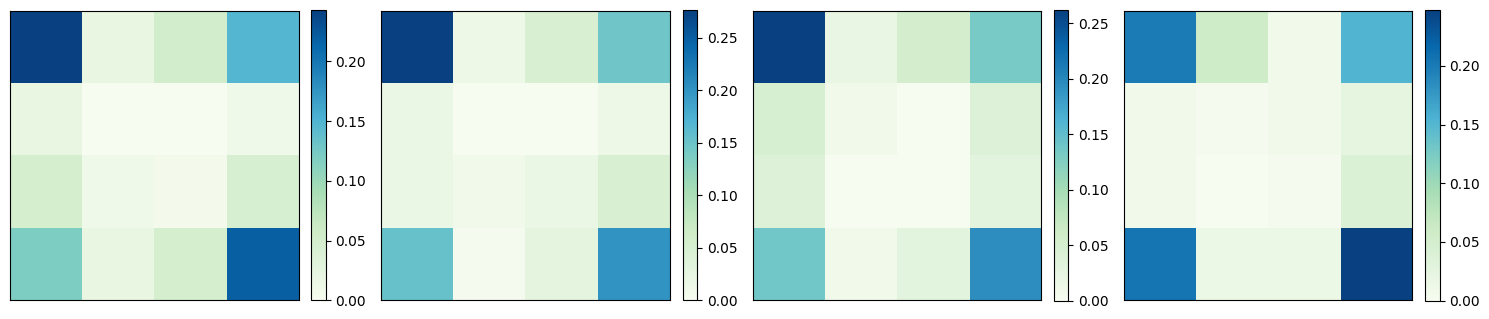

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_tendency.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

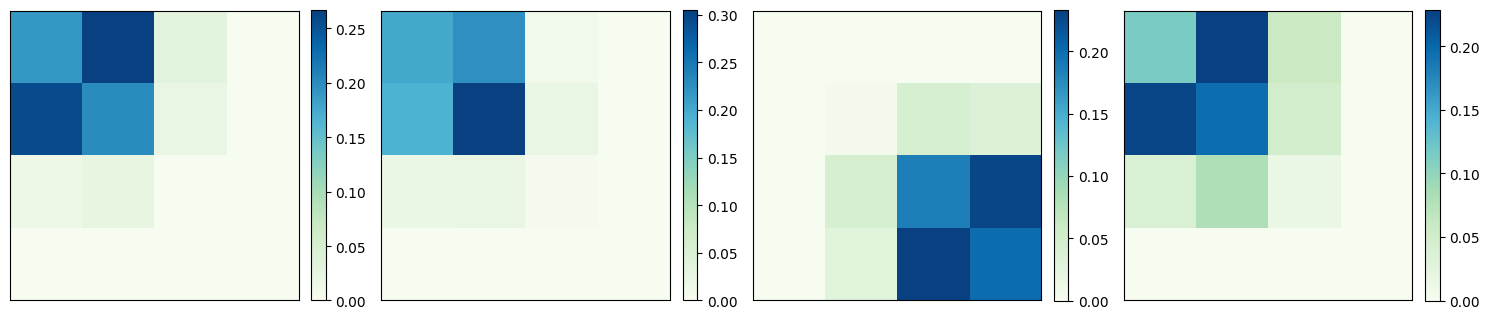

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_tendency.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Contrast

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i - j)^2 p(i, j) $$

In [8]:
df_contrast = df.sort_values(by=["contrast"])[['contrast', 'glcm', 'image']].reset_index()

df_contrast

,index,contrast,glcm,image
0,3017,0.647619,"[[0.1761904761904762, 0.19047619047619047, 0.0...","[[3, 2, 1, 1, 1, 2, 1, 3], [1, 1, 0, 0, 0, 0, ..."
1,4456,0.761905,"[[0.0, 0.0, 0.01904761904761905, 0.0], [0.0047...","[[3, 2, 2, 3, 2, 2, 2, 1], [3, 2, 3, 3, 3, 3, ..."
2,4622,0.785714,"[[0.0, 0.0, 0.009523809523809525, 0.0], [0.0, ...","[[2, 3, 3, 1, 3, 3, 3, 3], [2, 2, 2, 2, 3, 3, ..."
3,3070,0.804762,"[[0.14285714285714285, 0.23809523809523808, 0....","[[1, 0, 1, 1, 0, 0, 1, 0], [0, 2, 1, 1, 0, 1, ..."
4,4879,0.814286,"[[0.0, 0.0, 0.023809523809523808, 0.0047619047...","[[0, 2, 3, 3, 3, 2, 2, 2], [2, 2, 3, 3, 3, 2, ..."
...,...,...,...,...
5995,5960,4.600000,"[[0.14761904761904762, 0.014285714285714285, 0...","[[1, 0, 0, 3, 3, 0, 0, 3], [0, 3, 3, 3, 0, 0, ..."
5996,5795,4.614286,"[[0.14761904761904762, 0.0, 0.0142857142857142...","[[3, 1, 0, 0, 3, 0, 3, 0], [0, 3, 0, 3, 3, 0, ..."
5997,5470,4.628571,"[[0.2523809523809524, 0.023809523809523808, 0....","[[0, 0, 3, 3, 0, 0, 3, 0], [3, 3, 3, 3, 0, 0, ..."
5998,5848,4.638095,"[[0.20952380952380953, 0.02857142857142857, 0....","[[2, 0, 0, 3, 0, 3, 1, 3], [3, 3, 3, 0, 3, 0, ..."


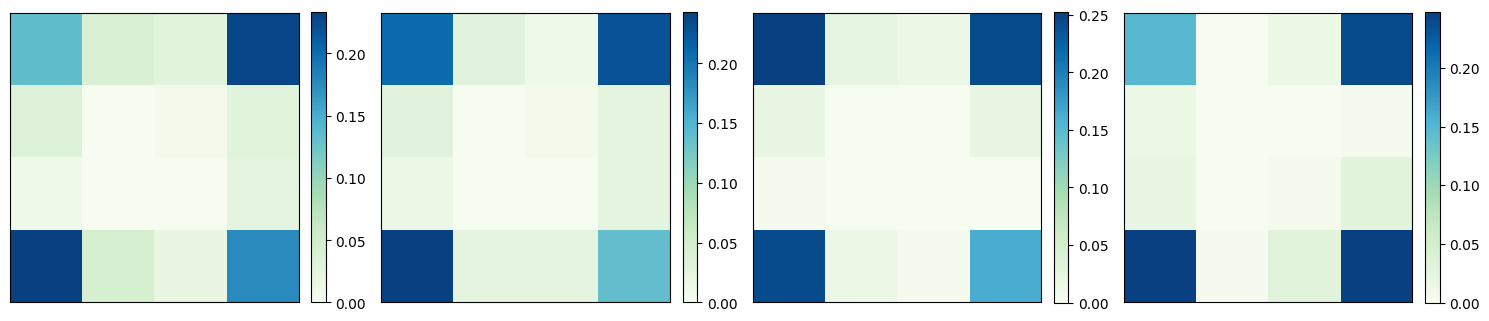

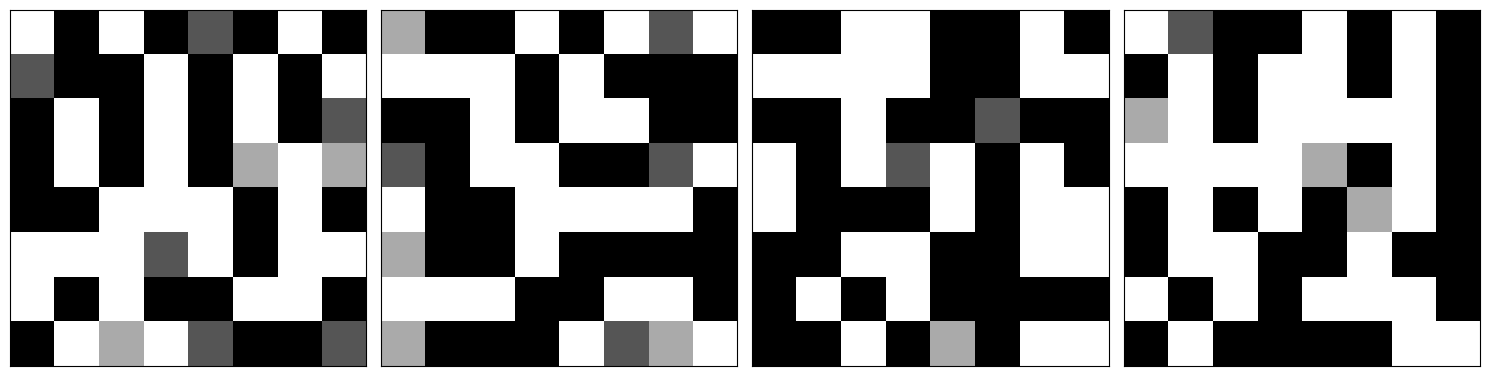

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[5999-i]['image'], cmap='gray')
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

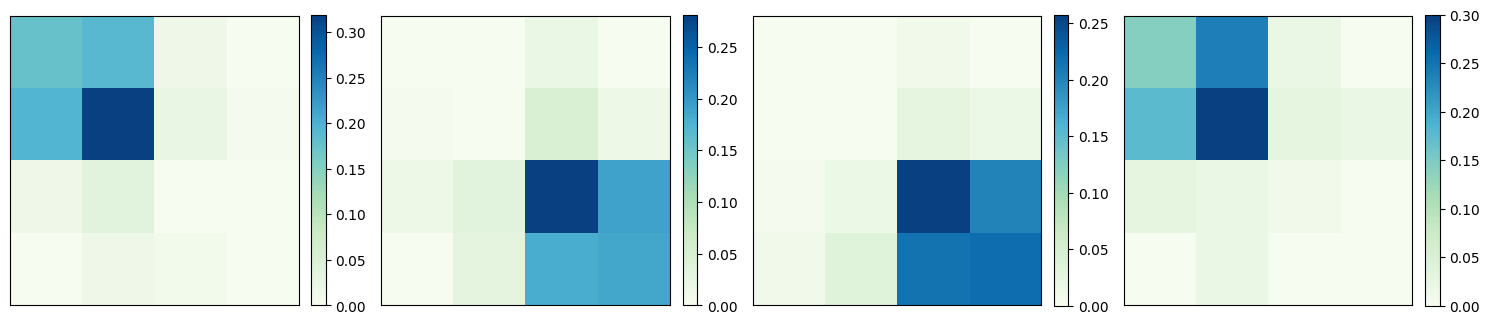

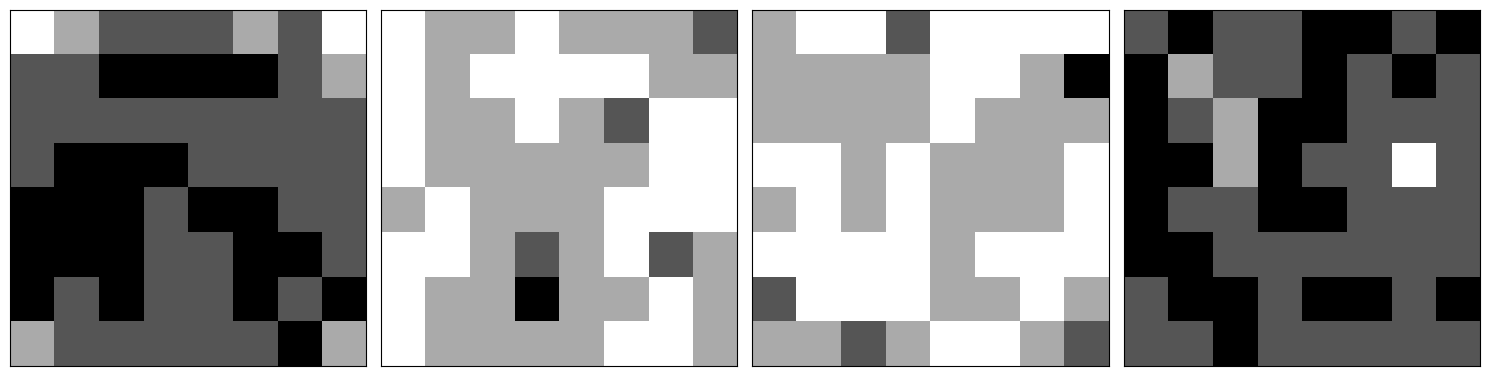

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[i]['image'], cmap='gray')
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Correlation

$$ \frac{\sum^{N_g}_{i=1}\sum^{N_g}_{j=1}{p(i,j)ij-\mu_x\mu_y}}{\sigma_x(i)\sigma_y(j)} $$

In [64]:
df_correlation = df.sort_values(by=["correlation"])[['correlation', 'glcm', 'image']].reset_index()

df_correlation

,index,correlation,glcm,image
0,3219,-0.226494,"[[0.09523809523809523, 0.1380952380952381, 0.0...","[[1, 0, 0, 3, 1, 3, 3, 0], [0, 3, 0, 1, 0, 1, ..."
1,5117,-0.191570,"[[0.1523809523809524, 0.02857142857142857, 0.0...","[[3, 0, 0, 3, 2, 0, 3, 0], [2, 0, 3, 0, 0, 3, ..."
2,5725,-0.189380,"[[0.1380952380952381, 0.0380952380952381, 0.01...","[[3, 3, 1, 0, 3, 3, 3, 3], [1, 0, 0, 3, 0, 0, ..."
3,1289,-0.189201,"[[0.319047619047619, 0.08571428571428572, 0.08...","[[0, 1, 0, 3, 0, 0, 0, 0], [0, 0, 0, 0, 2, 0, ..."
4,4527,-0.186036,"[[0.014285714285714285, 0.014285714285714285, ...","[[1, 2, 2, 2, 2, 0, 2, 3], [3, 2, 2, 3, 2, 3, ..."
...,...,...,...,...
5995,4890,0.248236,"[[0.023809523809523808, 0.03333333333333333, 0...","[[0, 1, 0, 1, 2, 3, 2, 1], [2, 2, 2, 2, 1, 3, ..."
5996,2458,0.253676,"[[0.03333333333333333, 0.02857142857142857, 0....","[[3, 0, 2, 2, 3, 3, 3, 3], [3, 1, 2, 3, 3, 3, ..."
5997,2669,0.256834,"[[0.05238095238095238, 0.01904761904761905, 0....","[[0, 2, 1, 3, 3, 3, 3, 3], [3, 0, 0, 3, 3, 3, ..."
5998,5955,0.262176,"[[0.18571428571428572, 0.0380952380952381, 0.0...","[[3, 3, 0, 3, 0, 0, 2, 3], [3, 3, 3, 3, 1, 0, ..."


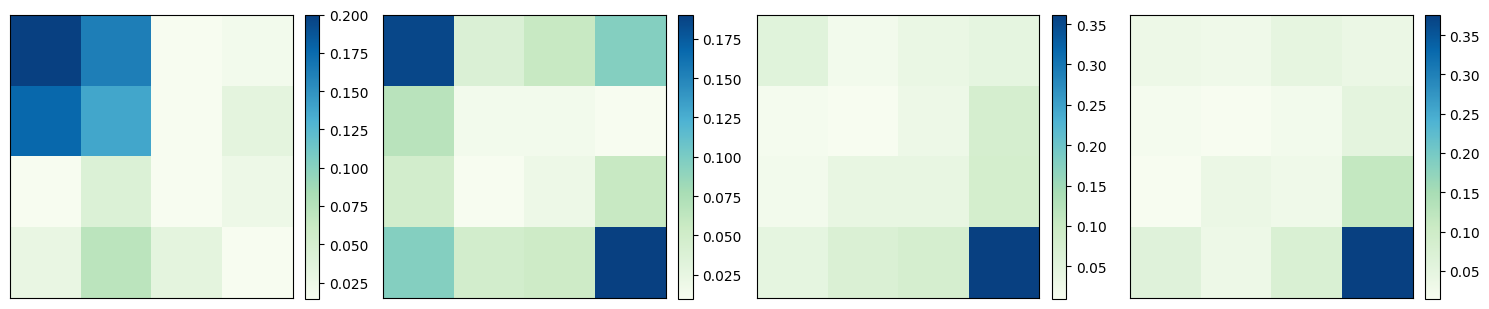

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_correlation.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

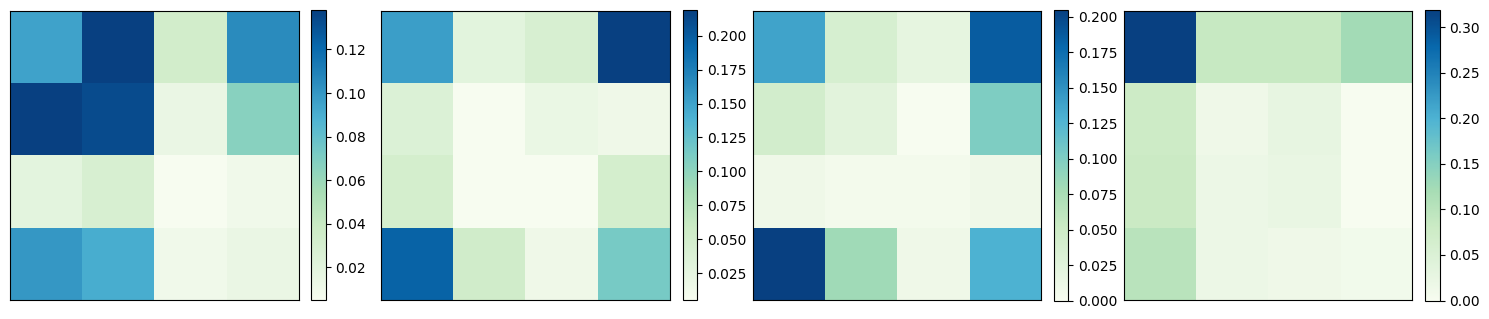

In [66]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_correlation.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Difference average

$$ \sum^{N_g-1}_{k=0}{kp_{x-y}(k)} $$

In [67]:
df_difference_average = df.sort_values(by=["difference_average"])[['difference_average', 'glcm', 'image']].reset_index()

df_difference_average

,index,difference_average,glcm,image
0,3663,0.519048,"[[0.2, 0.22380952380952382, 0.0095238095238095...","[[1, 1, 0, 0, 0, 2, 1, 0], [0, 1, 1, 1, 0, 1, ..."
1,4435,0.566667,"[[0.0, 0.0, 0.0, 0.009523809523809525], [0.0, ...","[[3, 3, 2, 2, 2, 1, 2, 3], [2, 3, 2, 3, 2, 2, ..."
2,3150,0.652381,"[[0.19047619047619047, 0.26666666666666666, 0....","[[1, 1, 0, 1, 0, 0, 2, 1], [0, 1, 0, 1, 0, 1, ..."
3,3786,0.657143,"[[0.19047619047619047, 0.2, 0.0285714285714285...","[[0, 1, 1, 1, 1, 1, 1, 0], [0, 1, 1, 0, 1, 3, ..."
4,3872,0.661905,"[[0.2761904761904762, 0.23333333333333334, 0.0...","[[0, 1, 1, 0, 1, 1, 0, 1], [0, 0, 0, 1, 1, 1, ..."
...,...,...,...,...
5995,5295,1.671429,"[[0.20952380952380953, 0.023809523809523808, 0...","[[0, 0, 0, 3, 3, 0, 3, 3], [0, 2, 2, 0, 0, 3, ..."
5996,5448,1.680952,"[[0.1761904761904762, 0.023809523809523808, 0....","[[3, 1, 1, 3, 0, 0, 0, 1], [3, 0, 0, 0, 3, 2, ..."
5997,5725,1.695238,"[[0.1380952380952381, 0.0380952380952381, 0.01...","[[3, 3, 1, 0, 3, 3, 3, 3], [1, 0, 0, 3, 0, 0, ..."
5998,5117,1.709524,"[[0.1523809523809524, 0.02857142857142857, 0.0...","[[3, 0, 0, 3, 2, 0, 3, 0], [2, 0, 3, 0, 0, 3, ..."


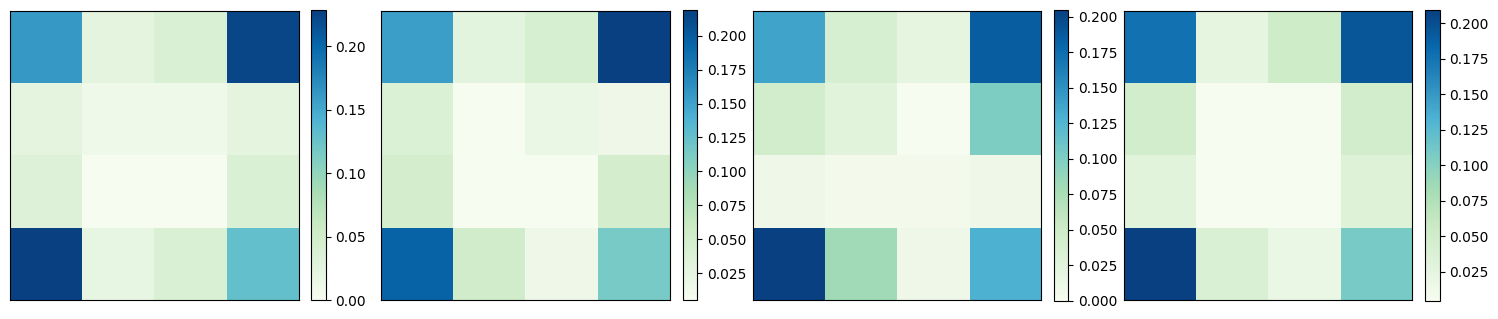

In [68]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_average.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

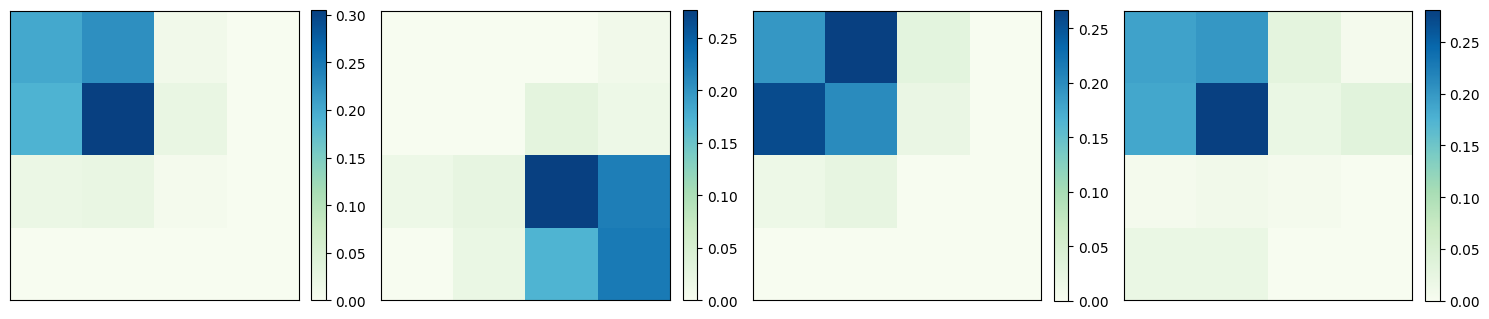

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_average.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Difference entropy

$$ -\sum_{k=0}^{N-1} p_{x-y}(k) \log p_{x-y}(k) $$

In [116]:
df_difference_entropy = df.sort_values(by=["difference_entropy"])[['difference_entropy', 'glcm', 'image']].reset_index()

df_difference_entropy

,index,difference_entropy,glcm,image
0,3663,0.801916,"[[0.2, 0.22380952380952382, 0.0095238095238095...","[[1, 1, 0, 0, 0, 2, 1, 0], [0, 1, 1, 1, 0, 1, ..."
1,3150,0.824052,"[[0.19047619047619047, 0.26666666666666666, 0....","[[1, 1, 0, 1, 0, 0, 2, 1], [0, 1, 0, 1, 0, 1, ..."
2,4402,0.869191,"[[0.0, 0.0, 0.0, 0.0], [0.0, 0.004761904761904...","[[2, 2, 3, 1, 3, 3, 3, 3], [1, 2, 3, 2, 2, 3, ..."
3,3872,0.883631,"[[0.2761904761904762, 0.23333333333333334, 0.0...","[[0, 1, 1, 0, 1, 1, 0, 1], [0, 0, 0, 1, 1, 1, ..."
4,4435,0.896585,"[[0.0, 0.0, 0.0, 0.009523809523809525], [0.0, ...","[[3, 3, 2, 2, 2, 1, 2, 3], [2, 3, 2, 3, 2, 2, ..."
...,...,...,...,...
5995,5988,1.384782,"[[0.06190476190476191, 0.03333333333333333, 0....","[[0, 0, 3, 3, 0, 2, 0, 0], [3, 2, 3, 3, 2, 3, ..."
5996,218,1.384810,"[[0.1380952380952381, 0.08095238095238096, 0.0...","[[2, 2, 0, 2, 2, 3, 3, 3], [3, 0, 1, 0, 0, 1, ..."
5997,5044,1.385348,"[[0.12857142857142856, 0.07142857142857142, 0....","[[2, 3, 0, 2, 3, 0, 3, 0], [0, 3, 2, 1, 0, 3, ..."
5998,5143,1.385513,"[[0.14285714285714285, 0.05714285714285714, 0....","[[3, 3, 3, 1, 0, 2, 0, 3], [1, 3, 0, 0, 2, 3, ..."


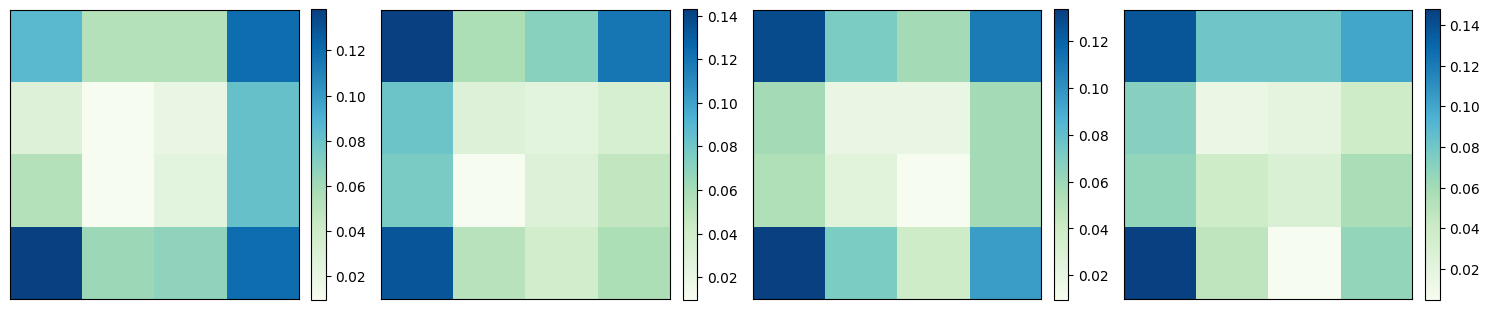

In [117]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_entropy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

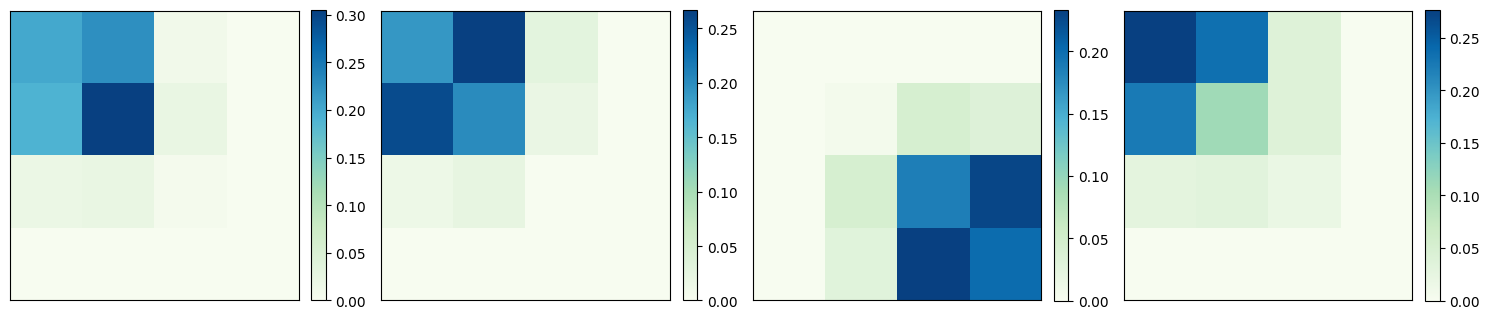

In [118]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_entropy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Difference variance

$$ \sum_{k=0}^{N-1} (k - \mu_{x-y})^2 p_{x-y}(k) $$


In [112]:
df_difference_variance = df.sort_values(by=["difference_variance"])[['difference_variance', 'glcm', 'image']].reset_index()

df_difference_variance

,index,difference_variance,glcm,image
0,3663,0.306780,"[[0.2, 0.22380952380952382, 0.0095238095238095...","[[1, 1, 0, 0, 0, 2, 1, 0], [0, 1, 1, 1, 0, 1, ..."
1,3150,0.312494,"[[0.19047619047619047, 0.26666666666666666, 0....","[[1, 1, 0, 1, 0, 0, 2, 1], [0, 1, 0, 1, 0, 1, ..."
2,4402,0.344422,"[[0.0, 0.0, 0.0, 0.0], [0.0, 0.004761904761904...","[[2, 2, 3, 1, 3, 3, 3, 3], [1, 2, 3, 2, 2, 3, ..."
3,3872,0.357120,"[[0.2761904761904762, 0.23333333333333334, 0.0...","[[0, 1, 1, 0, 1, 1, 0, 1], [0, 0, 0, 1, 1, 1, ..."
4,3612,0.366803,"[[0.11428571428571428, 0.22857142857142856, 0....","[[0, 2, 1, 1, 0, 1, 1, 1], [1, 0, 0, 0, 0, 2, ..."
...,...,...,...,...
5995,5816,1.919637,"[[0.1523809523809524, 0.0, 0.01904761904761905...","[[0, 3, 1, 3, 0, 3, 3, 3], [3, 0, 3, 3, 3, 3, ..."
5996,5295,1.944422,"[[0.20952380952380953, 0.023809523809523808, 0...","[[0, 0, 0, 3, 3, 0, 3, 3], [0, 2, 2, 0, 0, 3, ..."
5997,5729,1.963923,"[[0.17142857142857143, 0.014285714285714285, 0...","[[0, 0, 3, 3, 3, 0, 3, 0], [0, 0, 3, 3, 0, 3, ..."
5998,5579,1.973333,"[[0.18571428571428572, 0.004761904761904762, 0...","[[0, 3, 3, 3, 3, 0, 3, 3], [0, 0, 3, 3, 3, 0, ..."


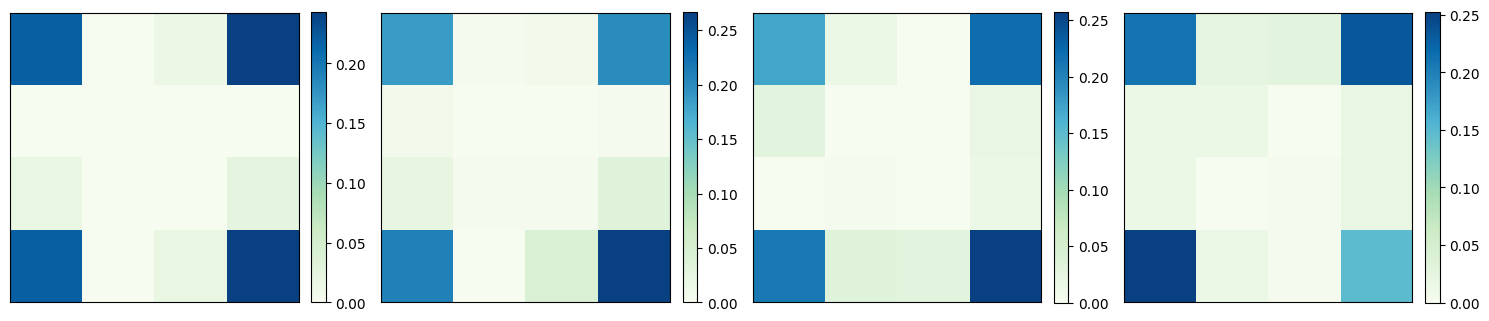

In [113]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_variance.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

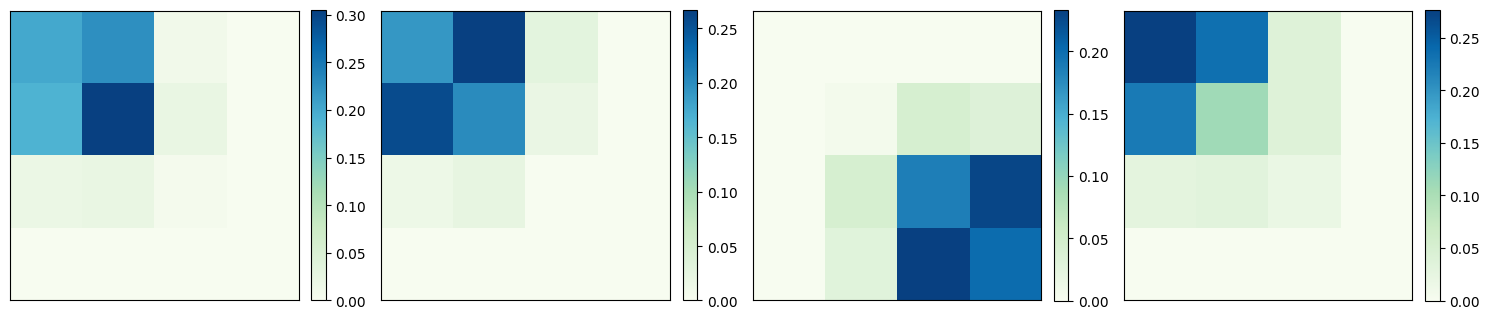

In [114]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_variance.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Energy

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} p(i, j)^2 $$

In [70]:
df_energy = df.sort_values(by=["energy"])[['energy', 'glcm', 'image']].reset_index()

df_energy

,index,energy,glcm,image
0,409,0.252875,"[[0.05714285714285714, 0.07142857142857142, 0....","[[2, 3, 3, 2, 0, 1, 3, 2], [0, 0, 1, 0, 0, 2, ..."
1,693,0.253591,"[[0.06190476190476191, 0.07142857142857142, 0....","[[1, 0, 3, 0, 1, 2, 2, 2], [3, 1, 2, 3, 0, 2, ..."
2,283,0.253591,"[[0.07142857142857142, 0.06190476190476191, 0....","[[1, 0, 1, 0, 1, 0, 1, 1], [1, 3, 0, 2, 3, 3, ..."
3,952,0.253680,"[[0.05714285714285714, 0.05238095238095238, 0....","[[2, 1, 0, 3, 2, 1, 0, 1], [1, 0, 3, 0, 2, 0, ..."
4,18,0.253770,"[[0.047619047619047616, 0.0761904761904762, 0....","[[0, 0, 3, 2, 3, 2, 2, 3], [1, 0, 2, 0, 3, 3, ..."
...,...,...,...,...
5995,1479,0.613898,"[[0.5952380952380952, 0.047619047619047616, 0....","[[0, 0, 0, 0, 0, 0, 3, 1], [0, 0, 0, 3, 0, 0, ..."
5996,2420,0.615595,"[[0.004761904761904762, 0.009523809523809525, ...","[[3, 0, 3, 3, 3, 1, 0, 3], [3, 3, 2, 3, 3, 3, ..."
5997,2377,0.627199,"[[0.0, 0.014285714285714285, 0.004761904761904...","[[1, 2, 3, 3, 2, 3, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5998,2734,0.628896,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."


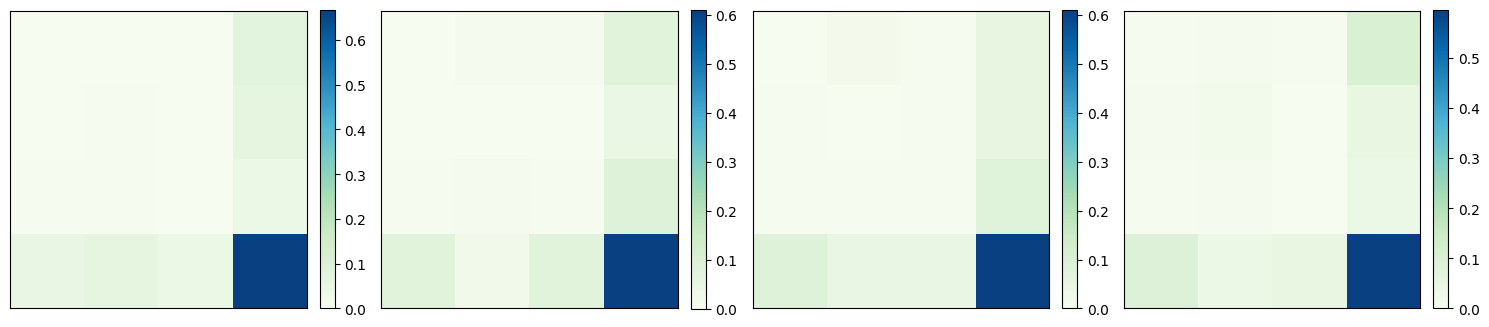

In [71]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_energy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

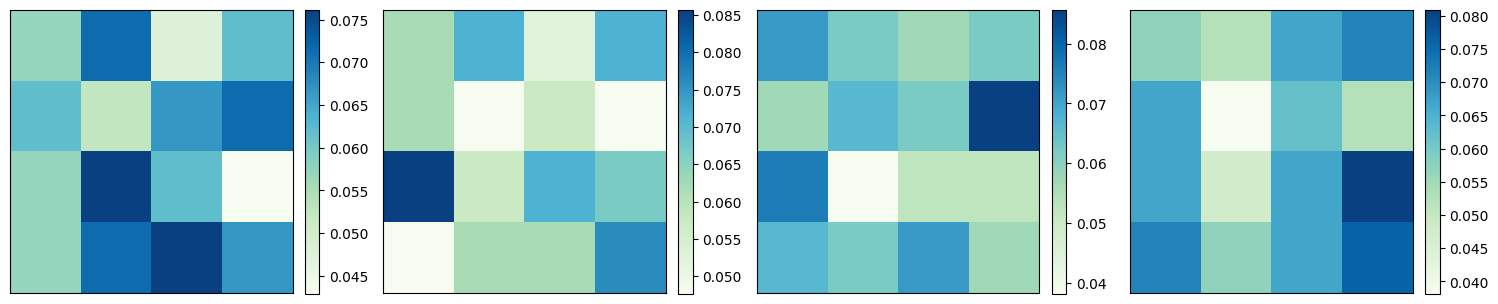

In [72]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_energy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Entropy

$$ -\sum_{i=1}^{N} \sum_{j=1}^{N} p(i, j) \log p(i, j) $$

In [75]:
df_entropy = df.sort_values(by=["entropy"])[['entropy', 'glcm', 'image']].reset_index()

df_entropy

,index,entropy,glcm,image
0,2697,1.273601,"[[0.0, 0.0, 0.0, 0.07142857142857142], [0.0, 0...","[[0, 3, 2, 1, 3, 0, 3, 0], [3, 3, 3, 3, 3, 3, ..."
1,2734,1.454601,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."
2,2377,1.493843,"[[0.0, 0.014285714285714285, 0.004761904761904...","[[1, 2, 3, 3, 2, 3, 3, 3], [3, 3, 2, 3, 0, 3, ..."
3,2420,1.536393,"[[0.004761904761904762, 0.009523809523809525, ...","[[3, 0, 3, 3, 3, 1, 0, 3], [3, 3, 2, 3, 3, 3, ..."
4,2417,1.537257,"[[0.02857142857142857, 0.014285714285714285, 0...","[[0, 3, 3, 3, 3, 3, 3, 2], [3, 3, 3, 3, 3, 0, ..."
...,...,...,...,...
5995,952,2.757114,"[[0.05714285714285714, 0.05238095238095238, 0....","[[2, 1, 0, 3, 2, 1, 0, 1], [1, 0, 3, 0, 2, 0, ..."
5996,18,2.757375,"[[0.047619047619047616, 0.0761904761904762, 0....","[[0, 0, 3, 2, 3, 2, 2, 3], [1, 0, 2, 0, 3, 3, ..."
5997,283,2.757839,"[[0.07142857142857142, 0.06190476190476191, 0....","[[1, 0, 1, 0, 1, 0, 1, 1], [1, 3, 0, 2, 3, 3, ..."
5998,693,2.758218,"[[0.06190476190476191, 0.07142857142857142, 0....","[[1, 0, 3, 0, 1, 2, 2, 2], [3, 1, 2, 3, 0, 2, ..."


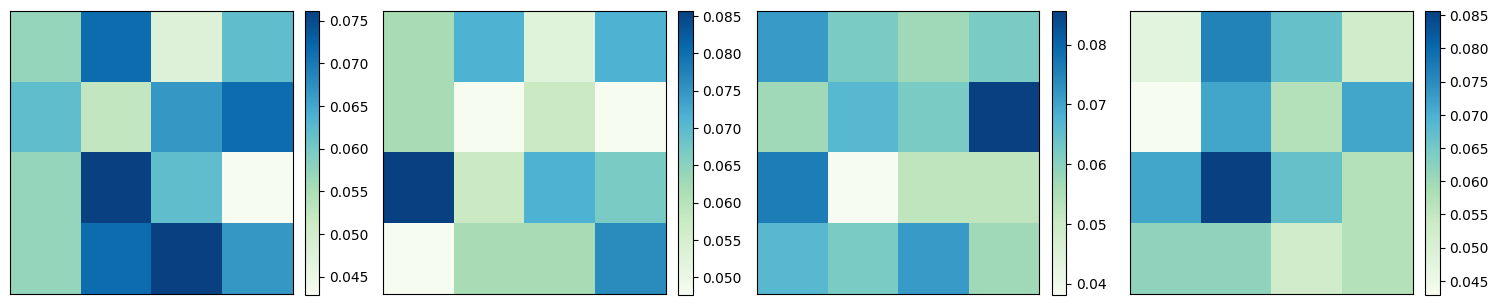

In [76]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_entropy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

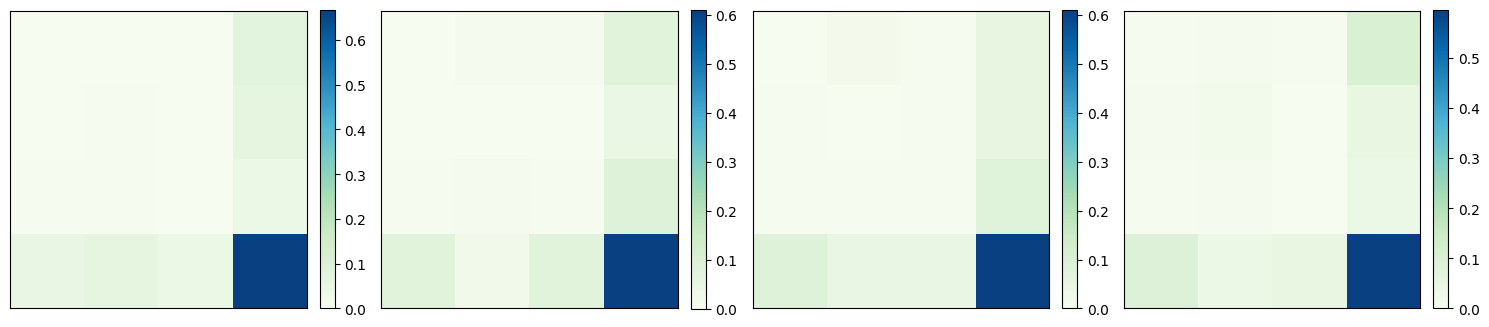

In [77]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_entropy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Homogeneity

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{p(i, j)}{1 + (i - j)^2} $$

See samples under Inverse difference moment.

## Information measure of correlation 1

$$ \frac{HXY-HXY1}{\max\{HX,HY\}} $$

In [78]:
df_imc1 = df.sort_values(by=["imc1"])[['imc1', 'glcm', 'image']].reset_index()

df_imc1

,index,imc1,glcm,image
0,2759,-0.068718,"[[0.04285714285714286, 0.0, 0.0476190476190476...","[[3, 0, 0, 0, 3, 3, 3, 3], [3, 2, 2, 2, 3, 0, ..."
1,1902,-0.064045,"[[0.5142857142857142, 0.047619047619047616, 0....","[[1, 0, 1, 0, 2, 0, 0, 0], [0, 0, 0, 0, 0, 0, ..."
2,4465,-0.062716,"[[0.023809523809523808, 0.01904761904761905, 0...","[[2, 3, 1, 2, 3, 3, 2, 2], [2, 0, 0, 3, 2, 2, ..."
3,1604,-0.061251,"[[0.3619047619047619, 0.08571428571428572, 0.1...","[[0, 2, 0, 0, 1, 0, 0, 2], [0, 2, 0, 0, 1, 1, ..."
4,2577,-0.059539,"[[0.014285714285714285, 0.014285714285714285, ...","[[3, 3, 3, 3, 3, 1, 1, 3], [3, 3, 3, 3, 3, 3, ..."
...,...,...,...,...
5995,1525,-0.001894,"[[0.3238095238095238, 0.047619047619047616, 0....","[[0, 0, 3, 3, 2, 2, 0, 0], [0, 3, 0, 0, 2, 0, ..."
5996,2966,-0.001812,"[[0.02857142857142857, 0.009523809523809525, 0...","[[3, 1, 3, 3, 3, 2, 1, 1], [3, 2, 3, 3, 3, 3, ..."
5997,1175,-0.001418,"[[0.5095238095238095, 0.0, 0.09047619047619047...","[[3, 0, 0, 0, 0, 0, 3, 0], [3, 0, 3, 0, 0, 0, ..."
5998,1366,-0.001271,"[[0.3761904761904762, 0.0, 0.06190476190476191...","[[0, 0, 3, 0, 0, 0, 3, 0], [3, 2, 0, 3, 3, 3, ..."


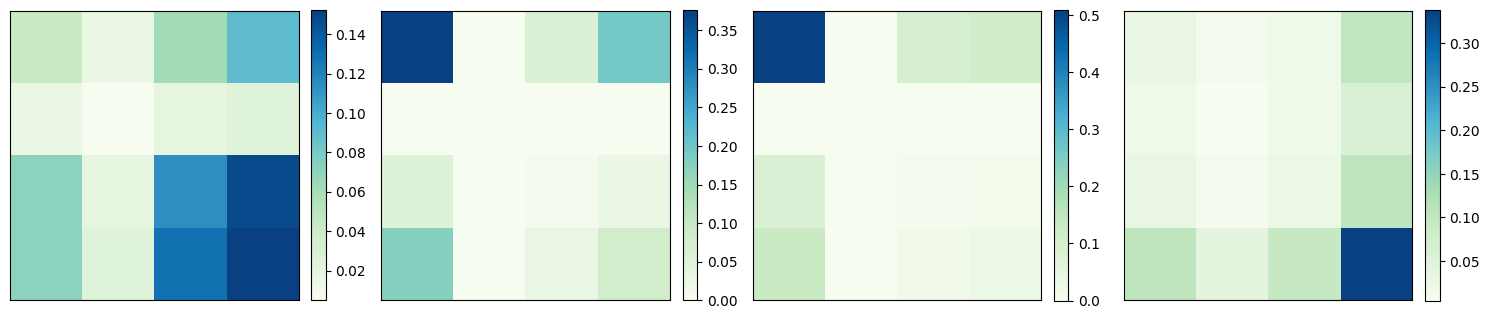

In [85]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc1.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

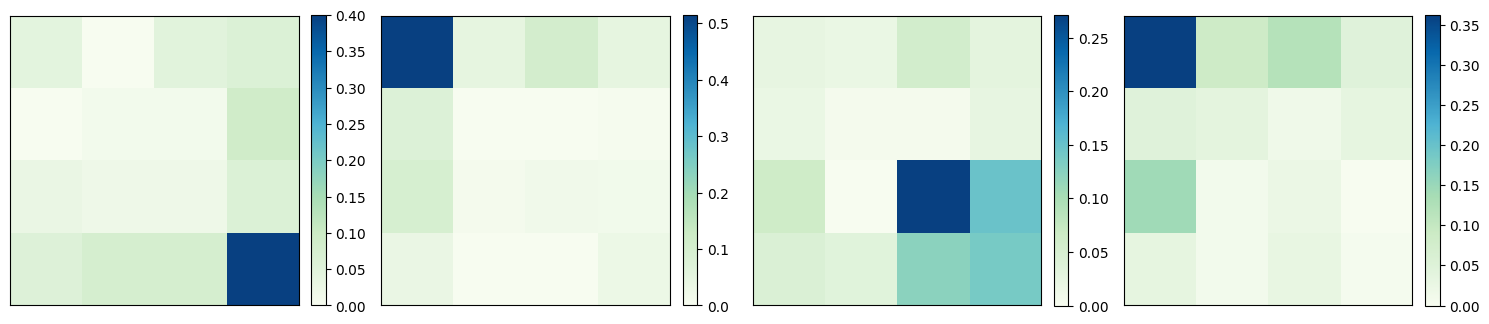

In [84]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc1.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Information measure of correlation 2

$$ \sqrt{1-e^{-2(HXY2-HXY)}} $$

In [86]:
df_imc2 = df.sort_values(by=["imc2"])[['imc2', 'glcm', 'image']].reset_index()

df_imc2

,index,imc2,glcm,image
0,1175,0.047195,"[[0.5095238095238095, 0.0, 0.09047619047619047...","[[3, 0, 0, 0, 0, 0, 3, 0], [3, 0, 3, 0, 0, 0, ..."
1,1366,0.047514,"[[0.3761904761904762, 0.0, 0.06190476190476191...","[[0, 0, 3, 0, 0, 0, 3, 0], [3, 2, 0, 3, 3, 3, ..."
2,4513,0.050617,"[[0.04285714285714286, 0.014285714285714285, 0...","[[0, 0, 2, 0, 2, 3, 3, 2], [0, 3, 3, 3, 2, 3, ..."
3,2544,0.061176,"[[0.014285714285714285, 0.014285714285714285, ...","[[3, 3, 2, 3, 3, 3, 0, 3], [0, 3, 1, 3, 3, 3, ..."
4,5208,0.061392,"[[0.21904761904761905, 0.0, 0.0142857142857142...","[[3, 3, 2, 3, 0, 0, 0, 0], [0, 0, 0, 3, 3, 0, ..."
...,...,...,...,...
5995,3197,0.357684,"[[0.2, 0.1619047619047619, 0.01428571428571428...","[[3, 2, 3, 1, 3, 3, 2, 3], [1, 2, 1, 1, 0, 1, ..."
5996,4465,0.369516,"[[0.023809523809523808, 0.01904761904761905, 0...","[[2, 3, 1, 2, 3, 3, 2, 2], [2, 0, 0, 3, 2, 2, ..."
5997,2759,0.373691,"[[0.04285714285714286, 0.0, 0.0476190476190476...","[[3, 0, 0, 0, 3, 3, 3, 3], [3, 2, 2, 2, 3, 0, ..."
5998,331,0.374529,"[[0.03333333333333333, 0.02857142857142857, 0....","[[1, 0, 0, 0, 3, 2, 3, 1], [0, 3, 3, 2, 2, 1, ..."


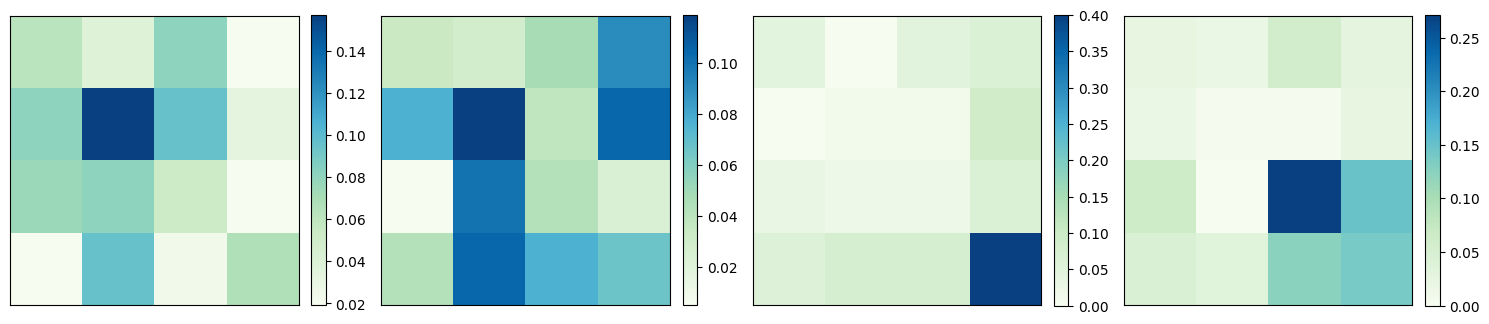

In [87]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc2.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

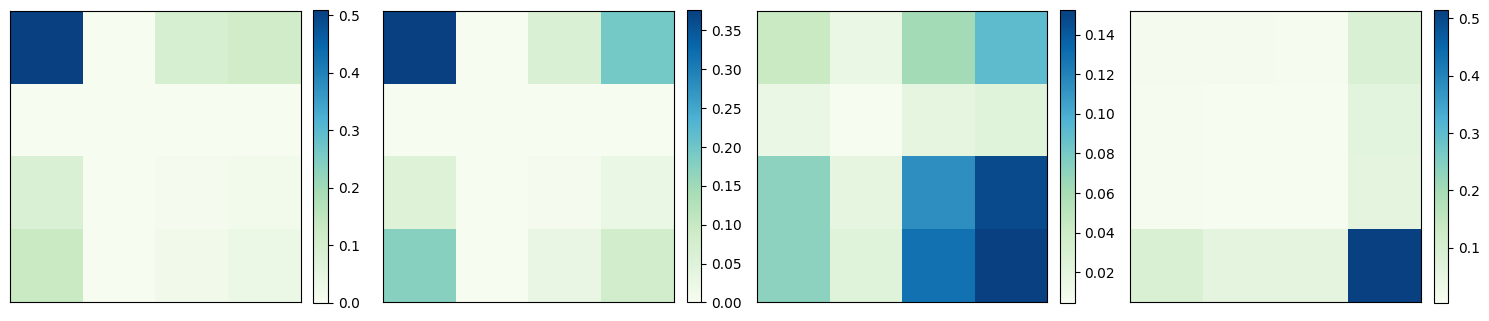

In [88]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc2.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Inverse difference

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{p(i, j)}{1 + |i - j|} $$

## Inverse Difference Moment

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{p(i, j)}{1 + |i - j|^2} $$

In [109]:
df_inverse_difference_moment = df.sort_values(by=["inverse_difference_moment"])[['inverse_difference_moment', 'glcm', 'image']].reset_index()

df_inverse_difference_moment

,index,inverse_difference_moment,glcm,image
0,5996,0.424762,"[[0.08095238095238096, 0.07142857142857142, 0....","[[0, 3, 1, 2, 1, 0, 0, 3], [1, 3, 3, 0, 0, 3, ..."
1,5117,0.425238,"[[0.1523809523809524, 0.02857142857142857, 0.0...","[[3, 0, 0, 3, 2, 0, 3, 0], [2, 0, 3, 0, 0, 3, ..."
2,5322,0.426667,"[[0.14285714285714285, 0.06666666666666667, 0....","[[0, 0, 3, 3, 0, 3, 2, 2], [3, 2, 3, 0, 2, 1, ..."
3,5919,0.428571,"[[0.1380952380952381, 0.04285714285714286, 0.0...","[[0, 3, 0, 3, 0, 0, 3, 1], [3, 0, 0, 0, 2, 0, ..."
4,5725,0.428571,"[[0.1380952380952381, 0.0380952380952381, 0.01...","[[3, 3, 1, 0, 3, 3, 3, 3], [1, 0, 0, 3, 0, 0, ..."
...,...,...,...,...
5995,2734,0.728571,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."
5996,4435,0.731905,"[[0.0, 0.0, 0.0, 0.009523809523809525], [0.0, ...","[[3, 3, 2, 2, 2, 1, 2, 3], [2, 3, 2, 3, 2, 2, ..."
5997,2052,0.735238,"[[0.004761904761904762, 0.0, 0.009523809523809...","[[3, 3, 3, 3, 3, 3, 3, 3], [3, 3, 3, 2, 3, 3, ..."
5998,3663,0.746190,"[[0.2, 0.22380952380952382, 0.0095238095238095...","[[1, 1, 0, 0, 0, 2, 1, 0], [0, 1, 1, 1, 0, 1, ..."


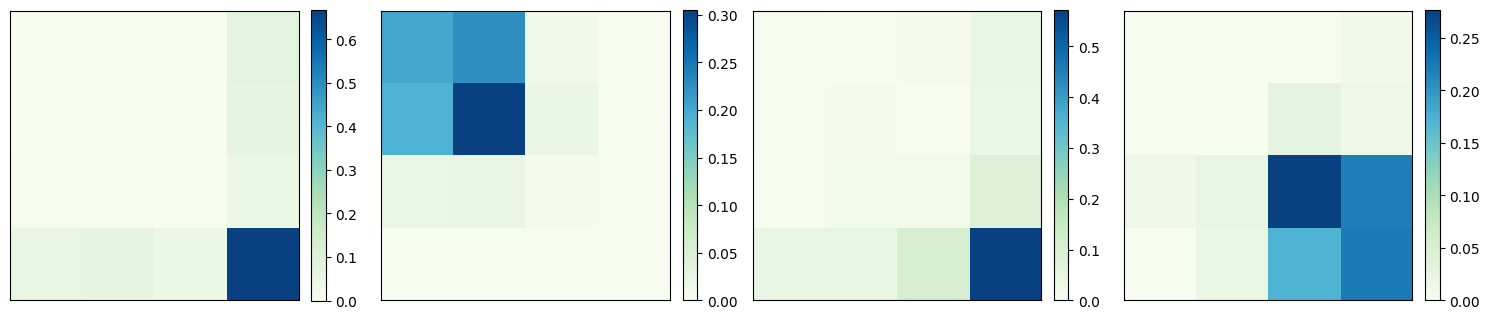

In [110]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_difference_moment.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

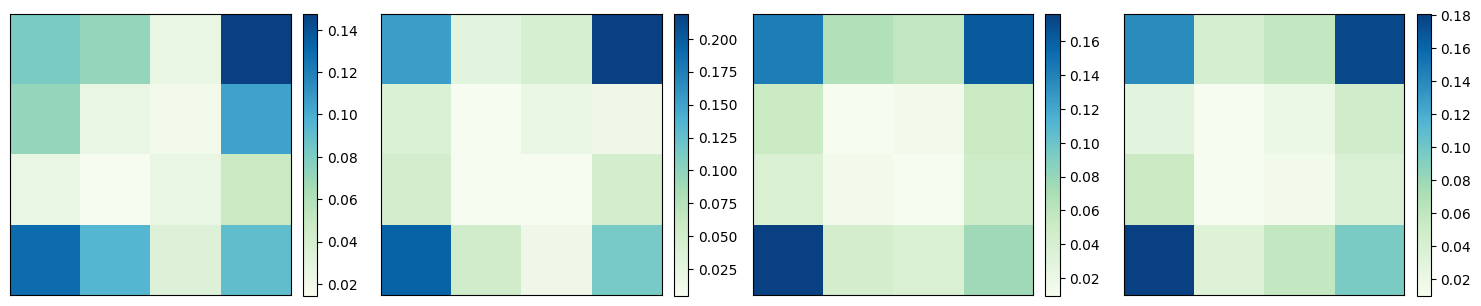

In [111]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_difference_moment.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Joint average

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} i \cdot p(i, j) $$

In [89]:
df_joint_average = df.sort_values(by=["joint_average"])[['joint_average', 'glcm', 'image']].reset_index()

df_joint_average

,index,joint_average,glcm,image
0,1147,1.423810,"[[0.5666666666666667, 0.09047619047619047, 0.0...","[[0, 0, 0, 3, 0, 0, 3, 0], [0, 0, 0, 0, 0, 0, ..."
1,1110,1.423810,"[[0.5142857142857142, 0.11904761904761904, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 0], [2, 1, 0, 0, 0, 1, ..."
2,1432,1.433333,"[[0.5666666666666667, 0.07142857142857142, 0.0...","[[0, 0, 2, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ..."
3,1159,1.457143,"[[0.5428571428571428, 0.07142857142857142, 0.0...","[[1, 0, 0, 0, 0, 2, 0, 0], [1, 2, 3, 0, 0, 1, ..."
4,1050,1.461905,"[[0.45714285714285713, 0.14285714285714285, 0....","[[0, 0, 0, 0, 2, 0, 0, 0], [0, 1, 0, 1, 0, 0, ..."
...,...,...,...,...
5995,2734,3.552381,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."
5996,2267,3.571429,"[[0.0, 0.014285714285714285, 0.0, 0.0285714285...","[[3, 3, 3, 0, 1, 3, 3, 3], [3, 1, 3, 3, 3, 3, ..."
5997,2377,3.571429,"[[0.0, 0.014285714285714285, 0.004761904761904...","[[1, 2, 3, 3, 2, 3, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5998,2697,3.604762,"[[0.0, 0.0, 0.0, 0.07142857142857142], [0.0, 0...","[[0, 3, 2, 1, 3, 0, 3, 0], [3, 3, 3, 3, 3, 3, ..."


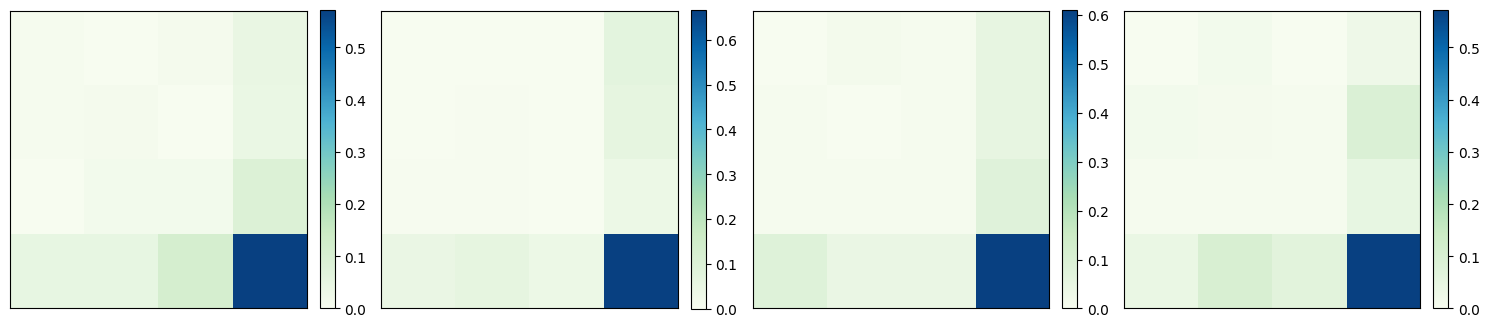

In [90]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_joint_average.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

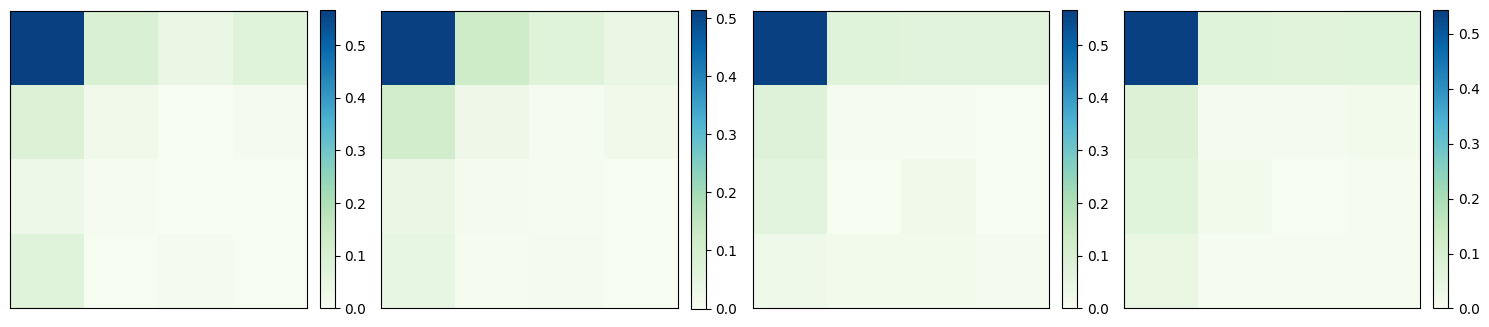

In [91]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_joint_average.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Maximum probability

$$ \max\big(p(i,j)\big) $$

In [92]:
df_max_probability = df.sort_values(by=["maximum_probability"])[['maximum_probability', 'glcm', 'image']].reset_index()

df_max_probability

,index,maximum_probability,glcm,image
0,843,0.076190,"[[0.0380952380952381, 0.047619047619047616, 0....","[[3, 1, 1, 1, 2, 3, 3, 2], [1, 0, 2, 2, 0, 1, ..."
1,409,0.076190,"[[0.05714285714285714, 0.07142857142857142, 0....","[[2, 3, 3, 2, 0, 1, 3, 2], [0, 0, 1, 0, 0, 2, ..."
2,137,0.080952,"[[0.06190476190476191, 0.0761904761904762, 0.0...","[[2, 2, 1, 2, 2, 0, 3, 3], [2, 1, 2, 3, 1, 0, ..."
3,164,0.080952,"[[0.06666666666666667, 0.0761904761904762, 0.0...","[[3, 3, 2, 0, 0, 0, 1, 0], [3, 0, 0, 0, 3, 1, ..."
4,466,0.080952,"[[0.05714285714285714, 0.06666666666666667, 0....","[[3, 3, 2, 3, 3, 1, 2, 0], [2, 0, 1, 1, 1, 2, ..."
...,...,...,...,...
5995,1479,0.595238,"[[0.5952380952380952, 0.047619047619047616, 0....","[[0, 0, 0, 0, 0, 0, 3, 1], [0, 0, 0, 3, 0, 0, ..."
5996,2420,0.595238,"[[0.004761904761904762, 0.009523809523809525, ...","[[3, 0, 3, 3, 3, 1, 0, 3], [3, 3, 2, 3, 3, 3, ..."
5997,2377,0.609524,"[[0.0, 0.014285714285714285, 0.004761904761904...","[[1, 2, 3, 3, 2, 3, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5998,2734,0.609524,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."


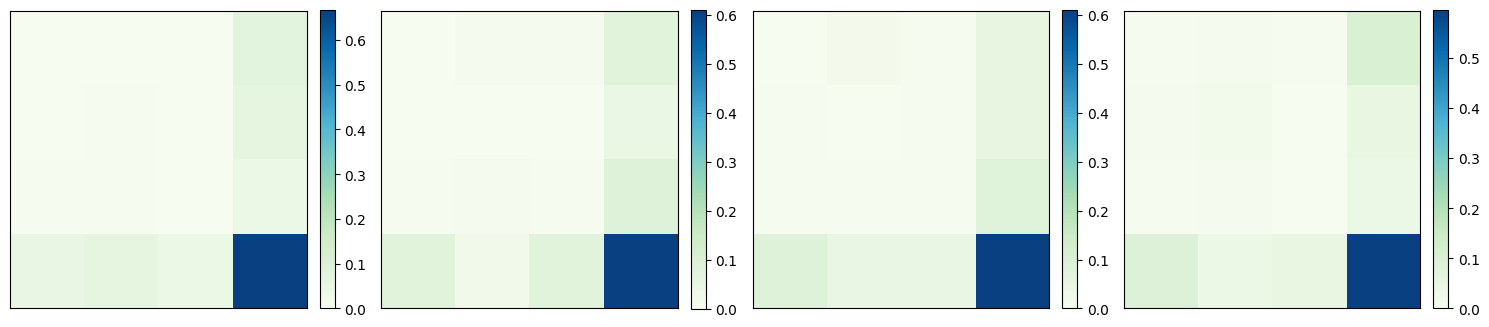

In [93]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_max_probability.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

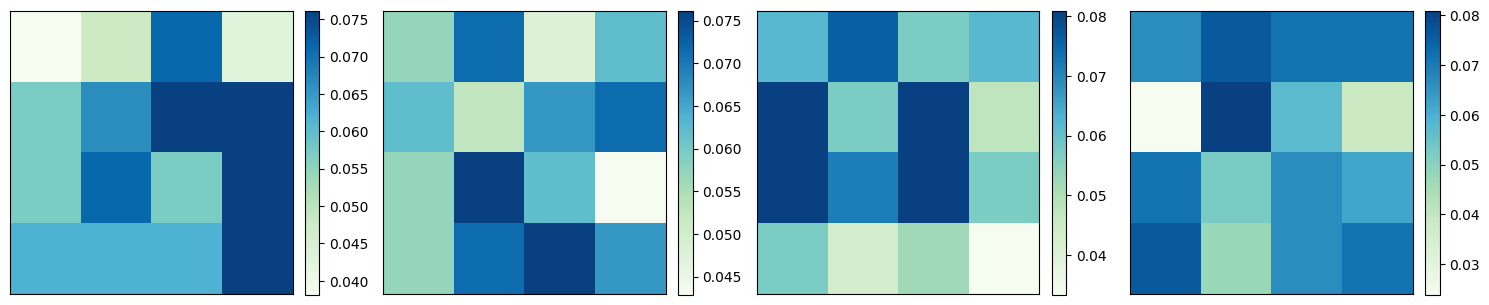

In [94]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_max_probability.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Sum average

$$ \sum^{2N}_{k=2}{k \cdot p_{x+y}(k)} $$

In [95]:
df_sum_average = df.sort_values(by=["sum_average"])[['sum_average', 'glcm', 'image']].reset_index()

df_sum_average

,index,sum_average,glcm,image
0,1147,2.885714,"[[0.5666666666666667, 0.09047619047619047, 0.0...","[[0, 0, 0, 3, 0, 0, 3, 0], [0, 0, 0, 0, 0, 0, ..."
1,1110,2.923810,"[[0.5142857142857142, 0.11904761904761904, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 0], [2, 1, 0, 0, 0, 1, ..."
2,1523,2.933333,"[[0.5666666666666667, 0.0380952380952381, 0.11...","[[2, 1, 1, 0, 0, 3, 0, 0], [0, 1, 0, 0, 0, 0, ..."
3,1403,2.947619,"[[0.49523809523809526, 0.10952380952380952, 0....","[[0, 0, 3, 0, 0, 1, 0, 1], [0, 0, 0, 2, 0, 0, ..."
4,1463,2.952381,"[[0.5571428571428572, 0.0761904761904762, 0.09...","[[0, 0, 0, 0, 0, 0, 3, 0], [0, 2, 0, 0, 0, 0, ..."
...,...,...,...,...
5995,2758,7.090476,"[[0.0, 0.0, 0.014285714285714285, 0.0523809523...","[[0, 2, 1, 3, 3, 3, 3, 3], [3, 3, 3, 0, 2, 1, ..."
5996,2377,7.119048,"[[0.0, 0.014285714285714285, 0.004761904761904...","[[1, 2, 3, 3, 2, 3, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5997,2052,7.161905,"[[0.004761904761904762, 0.0, 0.009523809523809...","[[3, 3, 3, 3, 3, 3, 3, 3], [3, 3, 3, 2, 3, 3, ..."
5998,2734,7.161905,"[[0.0, 0.009523809523809525, 0.009523809523809...","[[0, 3, 3, 3, 2, 0, 3, 3], [2, 1, 3, 3, 1, 3, ..."


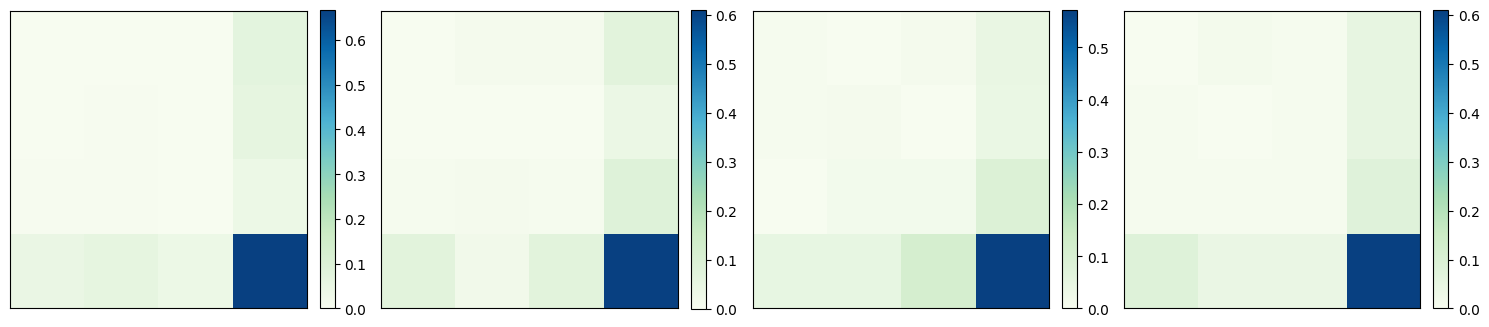

In [96]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_average.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

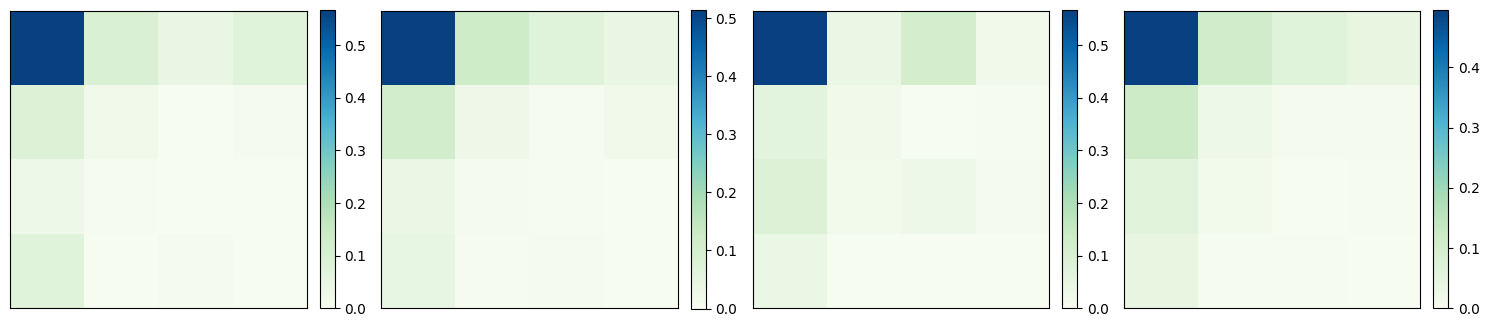

In [97]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_average.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Sum entropy

$$  - \sum^{2N}_{k=2}{p_{x+y}(k)\log p_{x+y}(k)} $$

In [8]:
df_sum_entropy = df.sort_values(by=["sum_entropy"])[['sum_entropy', 'glcm', 'image']].reset_index()

df_sum_entropy

,index,sum_entropy,glcm,image
0,2208,0.984289,"[[0.004761904761904762, 0.009523809523809525, ...","[[0, 3, 3, 3, 0, 1, 3, 3], [3, 3, 3, 3, 3, 3, ..."
1,1229,1.023847,"[[0.5857142857142857, 0.14285714285714285, 0.0...","[[0, 1, 0, 0, 0, 2, 0, 0], [0, 0, 0, 0, 0, 0, ..."
2,1234,1.110262,"[[0.6476190476190476, 0.03333333333333333, 0.0...","[[0, 0, 0, 0, 3, 0, 0, 0], [0, 0, 0, 0, 0, 3, ..."
3,5916,1.141806,"[[0.19047619047619047, 0.009523809523809525, 0...","[[0, 0, 3, 3, 3, 0, 0, 0], [0, 3, 3, 3, 3, 0, ..."
4,1708,1.148548,"[[0.6, 0.10952380952380952, 0.0333333333333333...","[[1, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
5995,5300,1.898244,"[[0.11428571428571428, 0.06190476190476191, 0....","[[0, 0, 1, 3, 0, 0, 3, 1], [0, 1, 0, 0, 2, 0, ..."
5996,515,1.900151,"[[0.08095238095238096, 0.06190476190476191, 0....","[[0, 0, 3, 1, 2, 3, 0, 0], [2, 1, 0, 2, 3, 2, ..."
5997,5277,1.904874,"[[0.11904761904761904, 0.06666666666666667, 0....","[[3, 0, 0, 0, 2, 0, 1, 3], [3, 2, 2, 0, 2, 3, ..."
5998,238,1.913610,"[[0.1, 0.07142857142857142, 0.0380952380952381...","[[0, 2, 2, 0, 2, 3, 1, 1], [0, 2, 3, 0, 0, 0, ..."


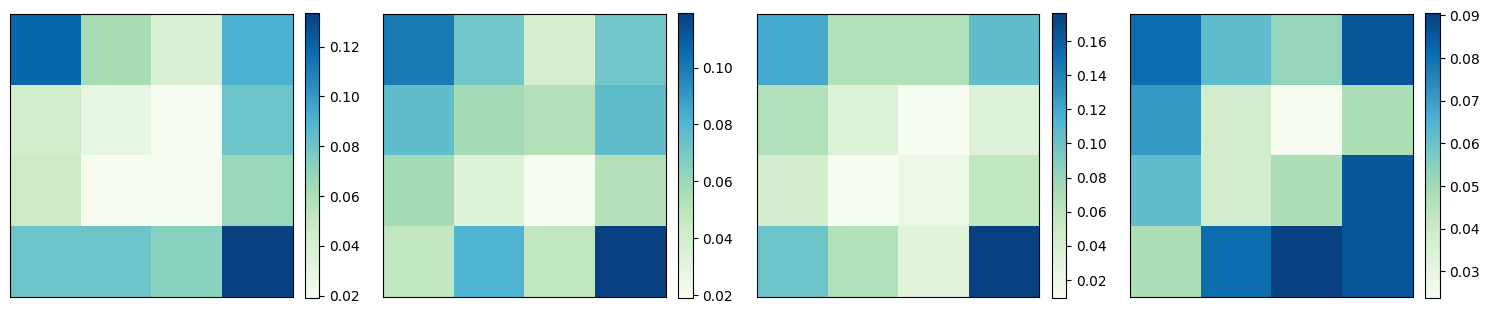

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_entropy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

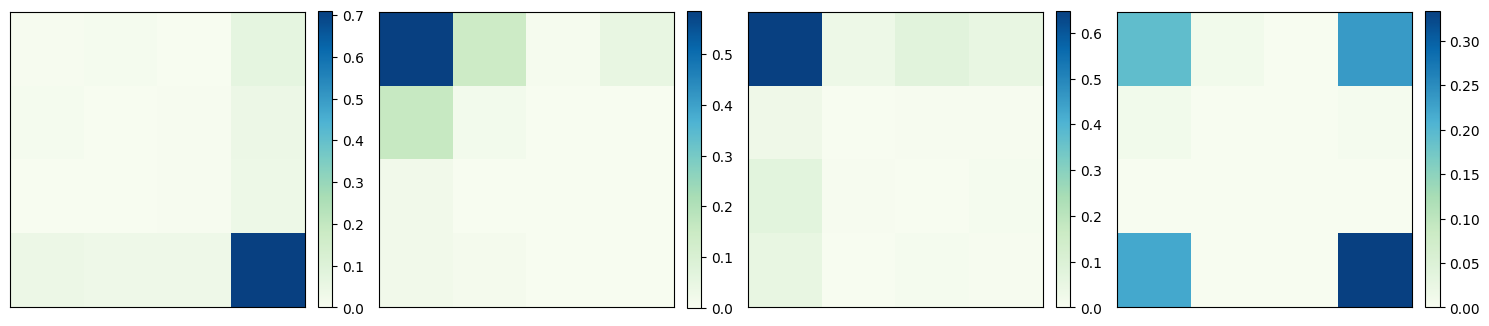

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_entropy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Sum of squares

$$ \sum^{N}_{i=1}\sum^{N}_{j=1}{(i-\mu_x)^2p(i,j)} $$

In [11]:
df_sum_of_squares = df.sort_values(by=["sum_of_squares"])[['sum_of_squares', 'glcm', 'image']].reset_index()

df_sum_of_squares

,index,sum_of_squares,glcm,image
0,4466,0.339433,"[[0.0, 0.0, 0.0, 0.0], [0.0, 0.004761904761904...","[[2, 3, 3, 2, 2, 2, 2, 2], [2, 2, 2, 3, 3, 2, ..."
1,4656,0.353651,"[[0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0095238095...","[[3, 2, 2, 3, 2, 2, 3, 2], [1, 3, 2, 2, 2, 3, ..."
2,4148,0.373787,"[[0.0, 0.0, 0.014285714285714285, 0.0047619047...","[[3, 2, 3, 2, 3, 3, 3, 3], [3, 2, 3, 3, 2, 3, ..."
3,3746,0.394558,"[[0.1619047619047619, 0.18095238095238095, 0.0...","[[1, 1, 1, 0, 0, 1, 1, 3], [0, 1, 1, 0, 1, 0, ..."
4,1229,0.417596,"[[0.5857142857142857, 0.14285714285714285, 0.0...","[[0, 1, 0, 0, 0, 2, 0, 0], [0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
5995,5723,2.073469,"[[0.2, 0.004761904761904762, 0.038095238095238...","[[0, 3, 0, 0, 0, 2, 2, 3], [0, 0, 0, 3, 2, 3, ..."
5996,5858,2.080748,"[[0.14285714285714285, 0.02857142857142857, 0....","[[0, 2, 0, 0, 3, 0, 0, 2], [3, 3, 3, 3, 0, 3, ..."
5997,5970,2.082290,"[[0.19523809523809524, 0.009523809523809525, 0...","[[0, 0, 0, 0, 0, 3, 3, 3], [0, 3, 2, 3, 0, 0, ..."
5998,5366,2.100590,"[[0.19523809523809524, 0.01904761904761905, 0....","[[0, 0, 0, 3, 0, 0, 3, 0], [0, 3, 3, 3, 3, 0, ..."


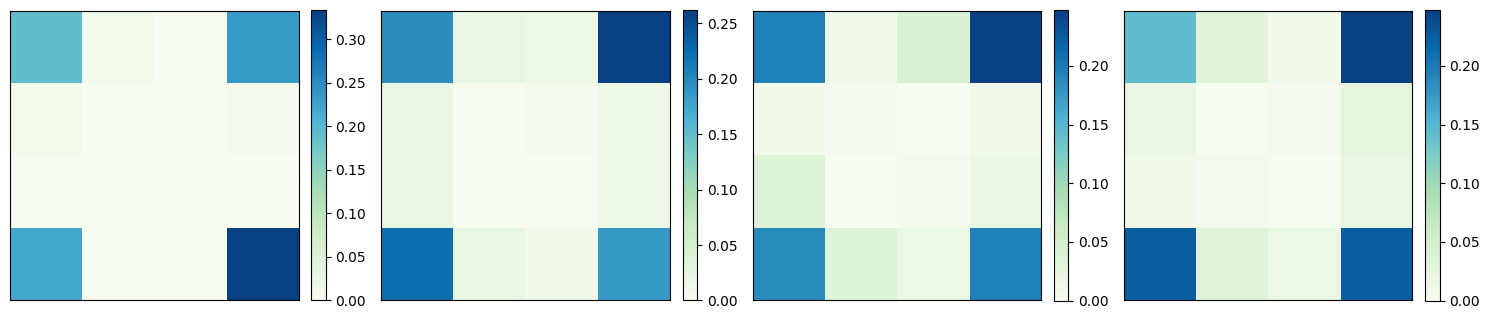

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_of_squares.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

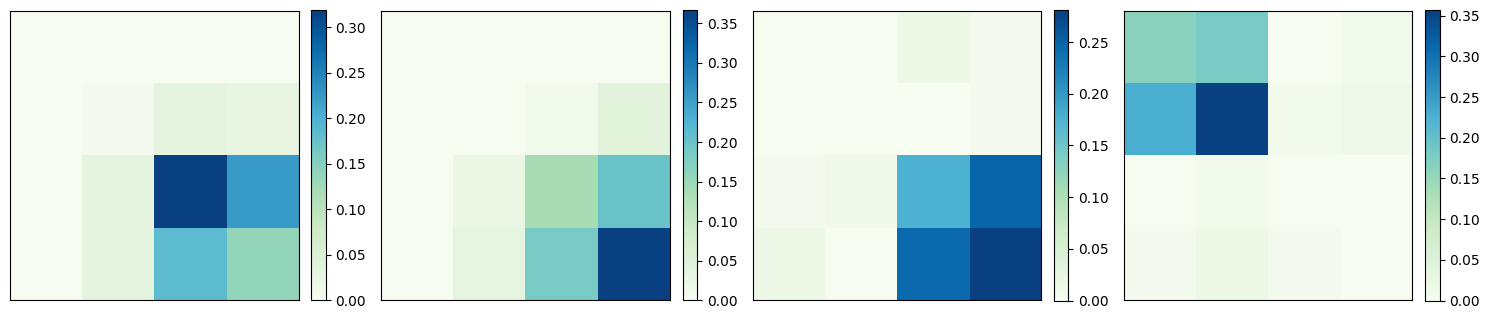

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_of_squares.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Maximal Correlation Coefficient

$$ \sqrt{\lambda_2 Q(i,j)} $$

$$ Q(i, j) = \displaystyle\sum^{N}_{k=0}{\frac{p(i,k)p(j, k)}{p_x(i)p_y(k)}} $$

In [98]:
df_mcc = df.sort_values(by=["maximal_correlation_coefficient"])[['maximal_correlation_coefficient', 'glcm', 'image']].reset_index()

df_mcc

,index,maximal_correlation_coefficient,glcm,image
0,4513,0.038749,"[[0.04285714285714286, 0.014285714285714285, 0...","[[0, 0, 2, 0, 2, 3, 3, 2], [0, 3, 3, 3, 2, 3, ..."
1,1366,0.039043,"[[0.3761904761904762, 0.0, 0.06190476190476191...","[[0, 0, 3, 0, 0, 0, 3, 0], [3, 2, 0, 3, 3, 3, ..."
2,1175,0.045463,"[[0.5095238095238095, 0.0, 0.09047619047619047...","[[3, 0, 0, 0, 0, 0, 3, 0], [3, 0, 3, 0, 0, 0, ..."
3,5208,0.048324,"[[0.21904761904761905, 0.0, 0.0142857142857142...","[[3, 3, 2, 3, 0, 0, 0, 0], [0, 0, 0, 3, 3, 0, ..."
4,636,0.049853,"[[0.047619047619047616, 0.06190476190476191, 0...","[[2, 1, 3, 0, 2, 2, 3, 1], [1, 0, 0, 1, 3, 3, ..."
...,...,...,...,...
5995,88,0.354991,"[[0.06190476190476191, 0.0380952380952381, 0.0...","[[3, 3, 3, 3, 0, 3, 1, 0], [3, 3, 3, 1, 1, 2, ..."
5996,1656,0.363967,"[[0.4380952380952381, 0.023809523809523808, 0....","[[2, 0, 0, 0, 0, 1, 0, 2], [0, 2, 0, 0, 2, 0, ..."
5997,3194,0.377969,"[[0.18571428571428572, 0.19047619047619047, 0....","[[1, 0, 0, 0, 1, 0, 0, 2], [1, 0, 1, 0, 1, 0, ..."
5998,3044,0.382494,"[[0.12857142857142856, 0.16666666666666666, 0....","[[1, 1, 2, 2, 0, 3, 1, 0], [0, 0, 0, 2, 0, 1, ..."


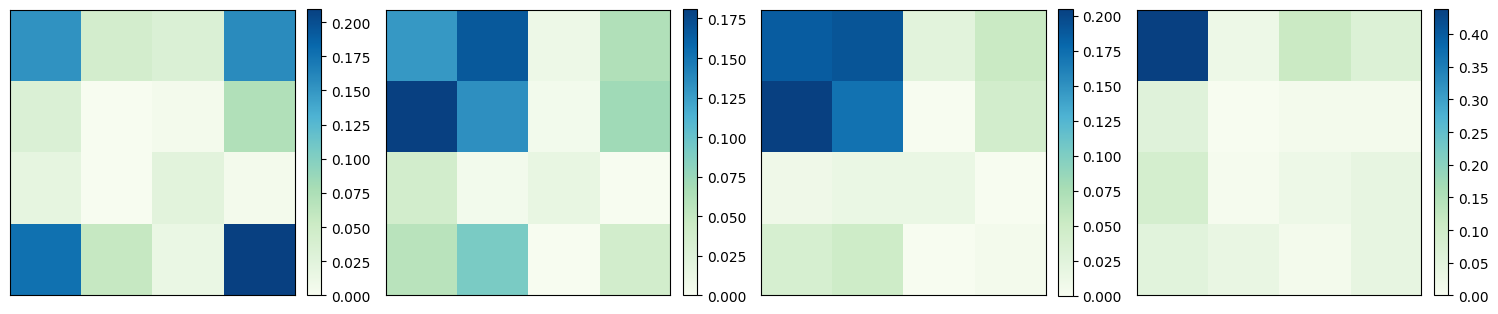

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_mcc.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

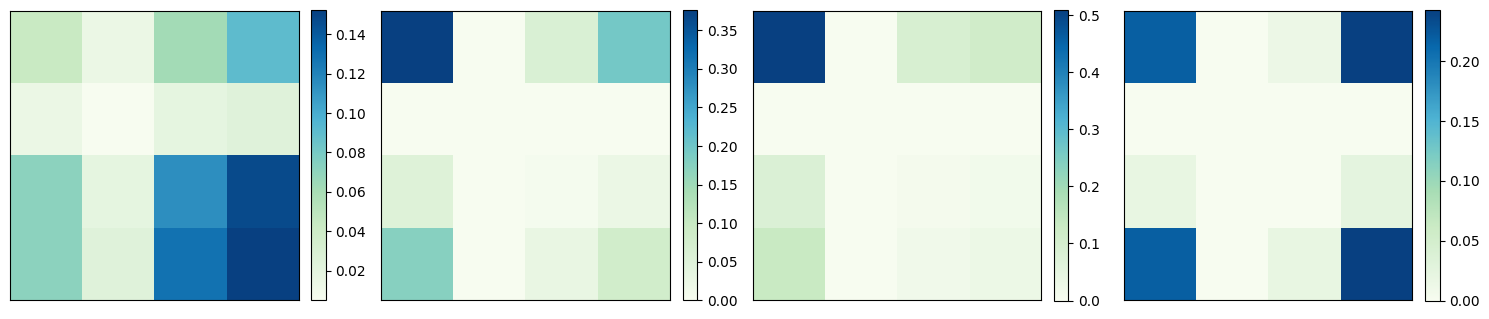

In [100]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_mcc.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Inverse variance

$$ \sum^{N-1}_{k=1}{\frac{p_{x-y}(k)}{k^2}} $$

In [101]:
df_inverse_variance = df.sort_values(by=["inverse_variance"])[['inverse_variance', 'glcm', 'image']].reset_index()

df_inverse_variance

,index,inverse_variance,glcm,image
0,5208,0.102513,"[[0.21904761904761905, 0.0, 0.0142857142857142...","[[3, 3, 2, 3, 0, 0, 0, 0], [0, 0, 0, 3, 3, 0, ..."
1,1175,0.103704,"[[0.5095238095238095, 0.0, 0.09047619047619047...","[[3, 0, 0, 0, 0, 0, 3, 0], [3, 0, 3, 0, 0, 0, ..."
2,2417,0.111640,"[[0.02857142857142857, 0.014285714285714285, 0...","[[0, 3, 3, 3, 3, 3, 3, 2], [3, 3, 3, 3, 3, 0, ..."
3,1648,0.117725,"[[0.49523809523809526, 0.0, 0.0666666666666666...","[[0, 0, 2, 0, 0, 0, 0, 3], [0, 3, 3, 0, 0, 0, ..."
4,1366,0.122222,"[[0.3761904761904762, 0.0, 0.06190476190476191...","[[0, 0, 3, 0, 0, 0, 3, 0], [3, 2, 0, 3, 3, 3, ..."
...,...,...,...,...
5995,3150,0.577381,"[[0.19047619047619047, 0.26666666666666666, 0....","[[1, 1, 0, 1, 0, 0, 2, 1], [0, 1, 0, 1, 0, 1, ..."
5996,3821,0.579497,"[[0.11428571428571428, 0.18095238095238095, 0....","[[0, 1, 1, 0, 1, 1, 0, 0], [0, 1, 1, 0, 1, 1, ..."
5997,4530,0.580952,"[[0.0, 0.0, 0.02857142857142857, 0.01904761904...","[[3, 3, 3, 3, 1, 2, 2, 3], [2, 2, 2, 2, 2, 2, ..."
5998,4991,0.587302,"[[0.0, 0.0, 0.004761904761904762, 0.0047619047...","[[2, 2, 2, 2, 3, 3, 1, 2], [2, 3, 2, 2, 2, 2, ..."


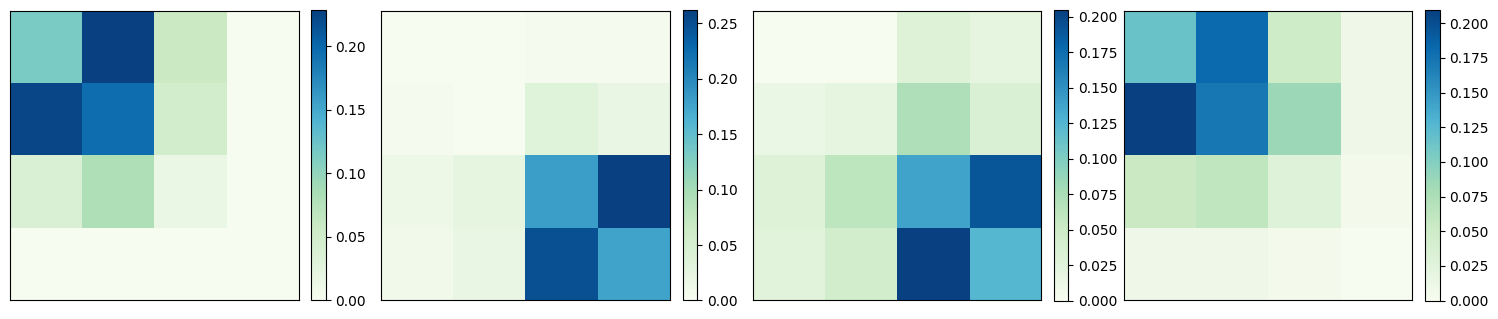

In [102]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_variance.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

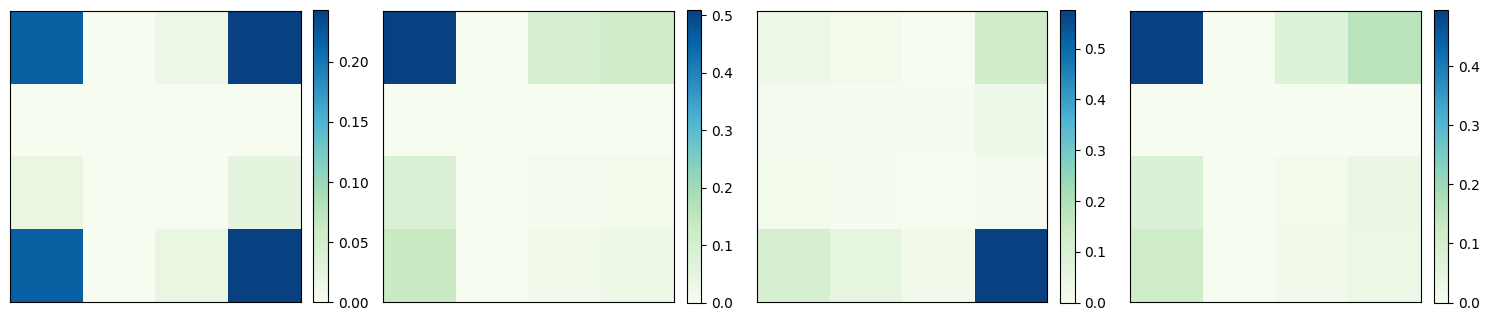

In [103]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_variance.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()